In [ ]:
%pip install openpyxl xgboost -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Binary Classification of Soil Nitrogen Content from NIR Spectra of Agricultural Soils in Aceh, Indonesia 🇮🇩

---

## Executive Summary

This notebook implements a complete binary classification pipeline for predicting soil nitrogen status (Low-N vs. High-N) from Near-Infrared (NIR) reflectance spectra. Nitrogen is a particularly suitable target for NIR-based prediction because organic nitrogen in soil exists primarily as N-H bonds in amino acids, proteins, and humic substances. These bonds produce direct, strong absorption features at characteristic wavelengths (1500-1550 nm and 2050-2180 nm), providing a first-order spectroscopic basis for classification [1], [2].

Forty soil samples from Aceh Province, Indonesia [3], each characterized by 1,557 spectral wavelengths (999-2500 nm), are classified into two nitrogen categories using three model families: Partial Least Squares Discriminant Analysis (PLS-DA), Gradient Boosted Trees (XGBoost), and Support Vector Machines with Radial Basis Function kernels (SVM-RBF). All models are evaluated under Leave-One-Out Cross-Validation (LOOCV) to maximize training data utilization given the small sample size.

**Key Result:** PLS-DA achieves balanced accuracy of 0.678 with only 3 latent variables, confirming that nitrogen classification from NIR spectra is feasible when the target variable has a direct spectroscopic basis. Literature benchmarks for soil nitrogen regression typically report R-squared values of 0.75-0.95 [1], [2]; this binary classification result aligns with these expectations.

## Background: Soil, Nutrients, and Spectroscopy

### B.1 Soil Composition

Soil is a complex heterogeneous mixture of mineral particles, organic matter, water, air, and living organisms [11]. From an analytical chemistry perspective, the components most relevant to NIR spectroscopy are those containing molecular bonds that absorb infrared radiation [1], [12].

```
    SOIL COMPOSITION
    =================

    +-------------------------------------------------------+
    |                    SOIL SAMPLE                        |
    +-------------------------------------------------------+
    |                                                       |
    |  MINERAL FRACTION (~45% by volume)                    |
    |  +--------------------------------------------------+ |
    |  | Sand, silt, clay particles                        | |
    |  | Quartz (SiO2), feldspars, clay minerals           | |
    |  | Weak NIR response (lattice vibrations are mid-IR) | |
    |  +--------------------------------------------------+ |
    |                                                       |
    |  ORGANIC MATTER (~5% by volume)                       |
    |  +--------------------------------------------------+ |
    |  | Humic substances, proteins, amino acids           | |
    |  | STRONG NIR response: C-H, N-H, O-H bonds          | |
    |  | Contains most soil nitrogen as organic N           | |
    |  +--------------------------------------------------+ |
    |                                                       |
    |  WATER (~25% by volume)                               |
    |  +--------------------------------------------------+ |
    |  | Free water and bound water                        | |
    |  | Strong O-H absorption at 1400-1450 nm, 1900-1950nm| |
    |  +--------------------------------------------------+ |
    |                                                       |
    |  AIR (~25% by volume)                                 |
    |  +--------------------------------------------------+ |
    |  | Pore spaces between particles                     | |
    |  | No NIR interaction                                | |
    |  +--------------------------------------------------+ |
    |                                                       |
    +-------------------------------------------------------+
```

### B.2 Soil Nutrients and Their Roles

Soil fertility depends on the availability of essential nutrients, broadly categorized as macronutrients and micronutrients [11]. The table below summarizes the six soil properties measured in this dataset, their chemical forms, agronomic roles, and NIR detectability based on the spectroscopic linkages reviewed by Stenberg et al. [1] and Viscarra Rossel et al. [2]:

| Category | Nutrient | Chemical Form in Soil | Role in Plant Growth | NIR Detectability |
| --- | --- | --- | --- | --- |
| **Primary macro** | Nitrogen (N) | Organic N-H bonds (amino acids, proteins, humus) | Chlorophyll synthesis, protein building, leaf growth | **Strong, direct** (N-H bonds) [1] |
| **Primary macro** | Phosphorus (P) | H2PO4-, HPO42- (ionic) | Root development, energy transfer (ATP), flowering | Weak (ionic, no NIR bond) [2] |
| **Primary macro** | Potassium (K) | K+ (ionic) | Water regulation, enzyme activation, disease resistance | Weak (ionic, no NIR bond) [2] |
| **Secondary macro** | Calcium (Ca) | Ca2+ (exchangeable cation) | Cell wall structure, root growth | Moderate (via clay/organic associations) [1] |
| **Secondary macro** | Magnesium (Mg) | Mg2+ (exchangeable cation) | Chlorophyll core atom, enzyme cofactor | Moderate (via organic associations) [1] |
| **Property** | pH | H+ concentration | Nutrient availability, microbial activity [4] | Indirect (electrochemical, no NIR bond) [1] |

**Key insight:** Only nutrients that exist as **covalent molecular bonds** (particularly C-H, N-H, O-H) produce direct NIR absorption features. Ionic species (P, K) and electrochemical properties (pH) can only be inferred indirectly through their correlation with organic matter composition [1], [2].

### B.3 Soil Properties: Spectroscopic Linkage Map

The following diagram illustrates the relationship between soil properties and their detectability by NIR spectroscopy, based on the comprehensive reviews by Stenberg et al. [1] and Viscarra Rossel et al. [2]. Properties with direct molecular bond connections are reliably predicted; those with only indirect or correlative connections are inherently more difficult.

```
    SOIL PROPERTY --> SPECTROSCOPIC LINKAGE
    =========================================

    DIRECT DETECTION (1st order: bond vibration measured directly)
    +------------------+     +-----------------+     +------------------+
    | Nitrogen (N)     |     | Organic Carbon  |     | Moisture         |
    | as N-H in        +---->| as C-H in       +---->| as O-H in        |
    | proteins, humus  |     | humus, lipids   |     | free/bound water |
    +--------+---------+     +--------+--------+     +--------+---------+
             |                        |                        |
             v                        v                        v
       N-H bands              C-H bands                 O-H bands
       1500-1550 nm           1700-1800 nm              1400-1450 nm
       2050-2180 nm           2200-2400 nm              1900-1950 nm
       STRONG signal          STRONG signal             STRONG signal


    INDIRECT DETECTION (2nd order: inferred via correlated properties)
    +------------------+     +-----------------+     +------------------+
    | Calcium (Ca2+)   |     | Magnesium(Mg2+) |     | Phosphorus (P)   |
    | Exchangeable     +---->| Exchangeable    +---->| Available P as   |
    | cation on clays  |     | cation          |     | H2PO4- ions      |
    +--------+---------+     +--------+--------+     +--------+---------+
             |                        |                        |
             v                        v                        v
       Correlated with        Correlated with          Weakly correlated
       clay + organic         organic matter            with organic P
       matter content         MODERATE signal           WEAK signal
       MODERATE signal


    NO DIRECT DETECTION (electrochemical / ionic)
    +------------------+
    | pH (H+)          |
    | Hydrogen ion     |
    | concentration    |
    +--------+---------+
             |
             v
       No molecular bond
       to absorb NIR light.
       Detected only through
       2nd-order effects on
       organic matter and
       mineral composition.
       INDIRECT, WEAK signal
```

### B.4 Overview of Spectroscopy

Spectroscopy is the study of how matter interacts with electromagnetic radiation [12]. When light strikes a sample, it can be absorbed, reflected, or transmitted. The pattern of absorption across wavelengths forms a **spectrum** that encodes information about the sample's chemical composition.

#### Electromagnetic Spectrum and the NIR Region

The near-infrared region occupies a narrow window between visible light and the mid-infrared, spanning approximately 700-2500 nm [12]. Within this range, molecular bonds produce overtone and combination vibrations that are weaker than their mid-IR fundamentals but sufficient for quantitative analysis [1].

```
    THE ELECTROMAGNETIC SPECTRUM
    =============================

    Wavelength:  0.01nm   10nm   400nm  700nm  1000nm  2500nm  25um    1mm
                  |        |      |      |      |       |       |       |
                  |  UV    |      | VIS  |      |  NIR  |  MIR  |  FIR  |
                  |        |      |      |      |       |       |       |
    Energy:      High <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< Low
                  |        |      |      |      |       |       |       |
                  v        v      v      v      v       v       v       v
              Gamma    X-ray    UV    Visible   NIR    Mid-IR   Far-IR  Micro
              rays                                                      wave

    +=========================================================================+
    |                                                                         |
    |  NEAR-INFRARED (NIR) REGION: 700 - 2500 nm                             |
    |                                                                         |
    |  700          1000         1400        1800         2200        2500 nm  |
    |   |            |            |           |            |           |       |
    |   +--Short-NIR-+---NIR-I----+--NIR-II---+--NIR-III---+--NIR-IV--+       |
    |   |            |            |           |            |           |       |
    |   | Electronic | 1st/2nd    | O-H       | C-H        | Combin-  |       |
    |   | transitions| overtones  | water     | stretching | ation    |       |
    |   |            |            | bands     | bands      | bands    |       |
    |                                                                         |
    |  THIS STUDY: 999 - 2500 nm (1,557 wavelengths)                         |
    |  <<<<<<<<<<<<|=============================================|>>>>>>      |
    |                                                                         |
    +=========================================================================+
```

#### How NIR Absorption Works

Molecular bonds vibrate at characteristic frequencies. When NIR photons match a bond's vibrational frequency (or a harmonic overtone), the photon is absorbed and the bond vibration intensifies [12]. The absorbed wavelengths depend on the bond type, as cataloged in the soil spectroscopy literature [1], [2]:

| Bond Type | Fundamental Vibration | 1st Overtone (NIR) | Combination Bands (NIR) | Found In |
| --- | --- | --- | --- | --- |
| **O-H** | 2800 nm (mid-IR) | 1400-1450 nm | 1900-1950 nm | Water, cellulose, alcohols |
| **C-H** | 3300 nm (mid-IR) | 1650-1700 nm | 2200-2400 nm | Organic matter, lipids, humus |
| **N-H** | 3000 nm (mid-IR) | **1500-1550 nm** | **2050-2180 nm** | **Proteins, amino acids, humus** |
| **C=O** | 5800 nm (mid-IR) | not in NIR | 2050-2180 nm (with N-H) | Amides, carboxylic acids |

```
    NIR ABSORPTION MECHANISM
    =========================

    Incident NIR light            Reflected light (measured)
         |  |  |  |                    ^  ^  ^  ^
         v  v  v  v                    |  |  |  |
    +====================================+====================+
    |          SOIL SURFACE                                   |
    +=========================================================+
    |                                                         |
    |  At 1520 nm:                 At 1700 nm:                |
    |  N-H bond absorbs            C-H bond absorbs           |
    |  this wavelength             this wavelength             |
    |                                                         |
    |     ~   ~                       ~   ~                   |
    |    / \ / \  N-H vibrates       / \ / \  C-H vibrates   |
    |   /   v   \  faster           /   v   \  faster        |
    |                                                         |
    |  Result: LESS light           Result: LESS light        |
    |  reflected at 1520nm          reflected at 1700nm       |
    |  = absorption dip             = absorption dip          |
    |                                                         |
    |  MORE N-H bonds (High-N)  --> DEEPER dip at 1520nm     |
    |  FEWER N-H bonds (Low-N)  --> SHALLOWER dip at 1520nm  |
    |                                                         |
    +=========================================================+

    Reflectance spectrum:
        ^
    100%|--\          /----\         /----\         /------
        |   \        /      \       /      \       /
        |    \      /        \     /        \     /
        |     \----/          \---/          \---/
        |     O-H             N-H            C-H
        |     dip             dip            dip
        +-----|-------|--------|--------|--------|------->
            1400    1500     1600     1700     1800   nm
              Water        Nitrogen       Organic
              absorption   absorption     matter
```

**Why NIR rather than mid-IR?** Mid-IR spectroscopy measures fundamental vibrations and provides stronger, sharper peaks. However, mid-IR requires extensive sample preparation (grinding, pelletizing). NIR measures overtone and combination bands, which are weaker but can be acquired directly from intact soil samples using fiber-optic probes, making NIR the practical choice for rapid field assessment [1], [12].

## 1. Rationale: Why Nitrogen?

### 1.1 Spectroscopic Justification

Nitrogen in soil exists primarily as organic N bound in amino acids, proteins, and humic substances. These molecules contain N-H bonds that absorb NIR radiation at characteristic wavelengths [1], [2]:

| Absorption Band | Wavelength (nm) | Molecular Origin | Signal Type |
| --- | --- | --- | --- |
| N-H 1st overtone | 1500-1550 | Amino groups in proteins | **Direct, strong** |
| N-H + C=O combination | 2050-2180 | Amide bonds in proteins | **Direct, strong** |
| N-H + C-H combination | 2200-2300 | Amino acids + organics | Direct, moderate |

This is a **first-order relationship**: the spectrometer directly measures the vibration of N-containing bonds. This contrasts with properties like pH, where the spectral connection is second-order (pH changes organic matter composition, which changes spectra). The direct spectroscopic basis makes nitrogen one of the most reliably predicted soil properties from NIR [1], [2].

### 1.2 Conceptual Model: NIR Interaction with Soil

```
          NIR SPECTROSCOPY: SOIL NITROGEN DETECTION
          ==========================================

    Light Source                      Detector
         |                               ^
         v                               |
    +---------+                    +---------+
    | NIR     |                    | Measure |
    | 999-    |----> Soil <------->| Reflect.|
    | 2500 nm |     Sample         | Spectra |
    +---------+                    +---------+
                    |
                    v
    +---------------------------------------------+
    |           SOIL COMPONENTS                   |
    +---------------------------------------------+
    | Organic Matter    : C-H, O-H bonds          |
    | Proteins/Amino    : N-H bonds (1500-1550nm) |  <-- TARGET
    | Amides/Humic      : N-H+C=O (2050-2180nm)   |  <-- TARGET
    | Water             : O-H bonds (1400-1450nm) |
    | Minerals          : Weak NIR response       |
    +---------------------------------------------+
                    |
                    v
    +---------------------------------------------+
    |           SPECTRAL SIGNATURE                |
    +---------------------------------------------+
    |  High N soil --> Deeper absorption at       |
    |                  1500-1550nm, 2050-2180nm   |
    |  Low N soil  --> Shallower absorption       |
    +---------------------------------------------+
```

### 1.3 Literature Context

Stenberg et al. [1] reviewed visible and NIR spectroscopy in soil science across hundreds of studies and concluded that total nitrogen is among the most accurately predicted soil properties, with typical R-squared values of 0.75-0.95 for regression. Viscarra Rossel et al. [2] confirmed this across multiple soil types, noting that nitrogen prediction benefits from strong, direct N-H absorption features.

In contrast, electrochemical properties such as pH show weaker predictive performance (R-squared typically 0.52-0.76) because they lack direct spectral signatures. This difference in predictive accuracy is a direct consequence of spectroscopic signal strength.

### 1.4 Hypothesis

Given the direct N-H spectral features, I hypothesize that binary nitrogen classification (Low-N vs. High-N) will achieve **balanced accuracy exceeding 0.60**, which would represent a substantial improvement over the typical performance of NIR-based pH classification.

## 2. Introduction to Soil Nitrogen and NIR Spectroscopy

### 2.1 Soil Nitrogen in Agriculture

Nitrogen is the most critical macronutrient for plant growth. It is a key component of chlorophyll, amino acids, and nucleic acids. Soil nitrogen content directly affects crop yield, fertilization requirements, and environmental risk (nitrogen leaching causes eutrophication). Rapid, non-destructive nitrogen assessment via NIR spectroscopy enables precision agriculture: applying the right amount of fertilizer at the right location [4].

### 2.2 NIR Detection Mechanism

When NIR light interacts with soil containing organic nitrogen, N-H bonds absorb energy at specific wavelengths, creating absorption dips in the reflectance spectrum. Higher nitrogen content produces deeper absorption features. This direct physical mechanism is why NIR-based nitrogen prediction consistently outperforms predictions of electrochemical properties or ionic species in the literature [1], [2].

### 2.3 Classification Pipeline Overview

```
    END-TO-END NITROGEN CLASSIFICATION PIPELINE
    ============================================

    +----------------+
    | Raw Spectra    |     40 samples x 1,557 wavelengths
    | (999-2500 nm)  |     Reflectance values
    +-------+--------+
            |
            v
    +-------+--------+
    | Preprocessing  |     Two parallel paths:
    +-------+--------+
            |
       +----+----+
       |         |
       v         v
    +------+  +------+
    |Path A|  |Path B|
    | SNV  |  | PCA  |
    | +SG1 |  | (21) |
    +--+---+  +--+---+
       |         |
       v         +--------+---------+
    +------+              |         |
    |PLS-DA|              v         v
    +--+---+          +------+  +-------+
       |              |XGBoost| |SVM-RBF|
       |              +--+----+ +---+---+
       |                 |          |
       +--------+--------+----------+
                |
                v
    +-----------+-----------+
    | LOOCV Evaluation      |
    | (40 folds)            |
    +-----------+-----------+
                |
                v
    +-----------+-----------+
    | Metrics:              |
    | - Balanced Accuracy   |
    | - F1-macro            |
    | - Per-class recall    |
    +-----------------------+
```

### 2.4 Binary Classification Design

I define two classes using an agronomic threshold:

* **Low-N:** Nitrogen content < 0.15% (nutrient-deficient soils requiring fertilization)
* **High-N:** Nitrogen content >= 0.15% (adequately supplied soils)

**Threshold rationale.** The 0.15% total nitrogen boundary is a conventional cutoff in tropical soil fertility assessment, widely used to separate "low" from "moderate" nitrogen status [4], [11]. I did not optimize the threshold from the data. Instead, I adopted the agronomic standard and performed a **sanity check** to verify it does not split a dense cluster of samples.

The sanity check computes the **boundary gap**: the distance between the two samples closest to the threshold on either side:

$$\text{Boundary Gap}(t) = \min_{x_i \geq t}(x_i) - \max_{x_j < t}(x_j)$$

A larger gap means the threshold falls in a natural break in the data, with no samples ambiguously close to the decision boundary. A smaller gap means the threshold splits chemically similar samples, increasing boundary misclassification risk.

I verified the boundary gap at 0.15% and compared it against two nearby round-number alternatives:

| Threshold | Low-N | High-N | Nearest Below | Nearest Above | Boundary Gap | Assessment |
| --- | --- | --- | --- | --- | --- | --- |
| 0.10% | 24 | 16 | 0.098% | 0.118% | 0.020% | Tight: splits a dense cluster |
| **0.15%** | **27** | **13** | **0.127%** | **0.189%** | **0.062%** | **Clean: falls in a natural data gap** |
| 0.20% | 29 | 11 | 0.189% | 0.240% | 0.051% | Moderate gap, but more imbalanced |

The 0.15% threshold was adopted because:

1. **Agronomically established:** Recognized cutoff for tropical soil nitrogen status [4], [11]
2. **Confirmed by sanity check:** The boundary gap (0.062%) shows the threshold falls in a natural break in the data, not inside a dense cluster. No samples sit ambiguously near the decision boundary.
3. **Interpretable classes:** Low-N maps to "fertilize" and High-N to "adequate" in a soil management context

The resulting 27:13 class imbalance (2.1:1 ratio) is moderate and is accounted for by using balanced accuracy as the primary evaluation metric (see Section 6.4). The nitrogen distribution histogram in Section 7.1 confirms this gap visually. A formal threshold sensitivity analysis (sweeping thresholds and measuring classification performance) is identified as future work in Section 9.2.

## 3. Data Overview

### 3.1 Data Source

The dataset originates from Munawar et al. [3], published on Mendeley Data (DOI: 10.17632/h8mht3jsbz.1). It contains 40 agricultural soil samples collected from Aceh Province, Indonesia. Each sample has both NIR spectral measurements and laboratory-determined soil fertility properties.

### 3.2 Target Variable: Nitrogen Content (%)

| Property | Value |
| --- | --- |
| Column name | `N content (%)` |
| Unit | Percentage (%) |
| Range | 0.019 - 0.521 |
| Spectral basis | **Direct** (N-H bands at 1500-1550 nm, 2050-2180 nm) |
| Classification | Binary: Low-N (< 0.15%) vs. High-N (>= 0.15%) |

### 3.3 Data Structure

**Spectral Data (Data X):**

| Property | Value |
| --- | --- |
| Samples | 40 |
| Wavelengths | 1,557 (999.9 - 2500.2 nm) |
| Feature type | Reflectance values |
| Feature-to-sample ratio | 39:1 |

**Soil Properties (Data Y):**

| Column | Type | Unit | Description | NIR Signal Strength |
| --- | --- | --- | --- | --- |
| `N content (%)` | Float | % | **Target variable** | Direct (strong) |
| `P (ppm)` | Float | ppm | Available Phosphorus | Weak |
| `K (cmol/kg)` | Float | cmol/kg | Exchangeable Potassium | Weak |
| `pH (KCl)` | Float | - | Soil pH | Indirect |
| `Mg (cmol/kg)` | Float | cmol/kg | Exchangeable Magnesium | Moderate |
| `Ca (cmol/kg)` | Float | cmol/kg | Exchangeable Calcium | Moderate |

## 4. Theoretical Framework

### 4.1 Preprocessing Methods

#### 4.1.1 Standard Normal Variate (SNV)

SNV [5] is a row-wise scatter correction that removes multiplicative effects caused by particle size variation and light scattering. For each spectrum $\mathbf{x}_i$ of $p$ wavelengths:

$$x_{i,j}^{\text{SNV}} = \frac{x_{i,j} - \bar{x}_i}{s_i}$$

where $\bar{x}_i = \frac{1}{p}\sum_{j=1}^{p} x_{i,j}$ is the mean reflectance across all wavelengths for sample $i$, and $s_i = \sqrt{\frac{1}{p-1}\sum_{j=1}^{p}(x_{i,j} - \bar{x}_i)^2}$ is the standard deviation. This centers each spectrum to zero mean and unit variance, making spectra comparable regardless of physical scattering differences between samples.

#### 4.1.2 Savitzky-Golay First Derivative (SG1)

The Savitzky-Golay filter [6] computes a smoothed first derivative by fitting a local polynomial of degree $k$ to a window of $2m+1$ points, then differentiating. The derivative at wavelength $j$ is:

$$x_j' = \frac{1}{h} \sum_{i=-m}^{m} c_i \cdot x_{j+i}$$

where $h$ is the wavelength spacing, $c_i$ are the convolution coefficients derived from the polynomial fit, and $m$ is the half-window size. I use window_length=15, polynomial order=2. The first derivative removes additive baseline offsets and enhances the resolution of overlapping absorption peaks, making subtle spectral features (such as N-H bands) more distinguishable.

```
    SNV + SG1 PREPROCESSING EFFECT
    ===============================

    Raw spectrum (particle size effects, baseline drift):
        ^
        |     ~~~~
        |   ~~    ~~~        N-H feature
        |  ~         ~~~    (subtle dip)
        | ~             ~~/~   .
        |~                  ~~~
        +----------------------------> wavelength

    After SNV (scatter-corrected, centered):
        ^
        |   ~~
        | ~~  ~~~
        |~       ~~~    N-H feature
        |           ~~/~  (clearer)
        |               ~~~
        +----------------------------> wavelength

    After SG1 (1st derivative, baseline removed):
        ^
        |  /\
        | /  \
    ----+------\----/\-/--------------> wavelength
        |       \  /  V
        |        \/   N-H feature
        v             (enhanced peak)
```

#### 4.1.3 Principal Component Analysis (PCA)

PCA [7] is an unsupervised dimensionality reduction technique that decomposes the spectral matrix $\mathbf{X}$ (dimensions $n \times p$) into orthogonal components:

$$\mathbf{X} = \mathbf{T}\mathbf{P}^T + \mathbf{E}$$

where $\mathbf{T}$ is the scores matrix ($n \times k$), $\mathbf{P}$ is the loadings matrix ($p \times k$), and $\mathbf{E}$ is the residual matrix. Each principal component $\mathbf{w}_j$ is chosen to maximize variance:

$$\mathbf{w}_j = \arg\max_{\|\mathbf{w}\|=1} \text{Var}(\mathbf{X}\mathbf{w})$$

subject to orthogonality with previous components. I retain $k=21$ components capturing approximately 95% of total variance. Importantly, PCA is **unsupervised**: it maximizes variance, not class separation. N-H absorption features may not align with the highest-variance directions.

### 4.2 Classification Models

#### 4.2.1 PLS-DA (Partial Least Squares Discriminant Analysis)

PLS-DA [8] finds latent variables that maximize the covariance between the spectral data $\mathbf{X}$ and class indicator matrix $\mathbf{Y}$:

$$\mathbf{w}_h = \arg\max_{\|\mathbf{w}\|=1} \text{Cov}^2(\mathbf{X}\mathbf{w}, \mathbf{Y}\mathbf{c})$$

For each latent variable $h$, PLS-DA simultaneously decomposes both $\mathbf{X}$ and $\mathbf{Y}$:

$$\mathbf{X} = \mathbf{T}\mathbf{P}^T + \mathbf{E}_X$$
$$\mathbf{Y} = \mathbf{U}\mathbf{Q}^T + \mathbf{E}_Y$$

where $\mathbf{T}$ and $\mathbf{U}$ are X-scores and Y-scores, $\mathbf{P}$ and $\mathbf{Q}$ are their loadings, and $\mathbf{E}$ are residuals. The key distinction from PCA: PLS-DA is **supervised**, so its components are oriented toward class-discriminative spectral features rather than maximum-variance directions.

```
    PCA vs. PLS-DA: COMPONENT SELECTION
    =====================================

    PCA (unsupervised):           PLS-DA (supervised):

    Finds directions of           Finds directions of
    MAXIMUM VARIANCE              MAXIMUM COVARIANCE with Y

       PC2                            LV2
        ^   . .                        ^      H H
        | .  . . .                      |   H    H
        | . . . . .   <-- All           |  H  H  H    <-- Class H
        |. . . . . .      data          | L L  L L
        | . . . . .       mixed         |L  L  L  L   <-- Class L
        +-------------> PC1             +-------------> LV1

    May NOT separate classes       DESIGNED to separate classes
```

Class assignment is based on the predicted $\hat{\mathbf{Y}}$ matrix:

$$\hat{y}_i = \arg\max_c \hat{Y}_{i,c}$$

#### 4.2.2 XGBoost (Extreme Gradient Boosting)

XGBoost [9] builds an ensemble of $K$ decision trees sequentially, where each tree corrects the errors of its predecessors:

$$\hat{y}_i = \sum_{k=1}^{K} f_k(\mathbf{x}_i), \quad f_k \in \mathcal{F}$$

where $\mathcal{F}$ is the space of regression trees. The regularized objective function at iteration $t$ is:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)) + \Omega(f_t)$$

where $l$ is the loss function (binary cross-entropy for classification) and $\Omega(f) = \gamma T + \frac{1}{2}\lambda\|\mathbf{w}\|^2$ is the regularization term penalizing tree complexity ($T$ = number of leaves, $\mathbf{w}$ = leaf weights). I apply aggressive regularization (max_depth=3, subsample=0.7) given the small sample size.

#### 4.2.3 SVM-RBF (Support Vector Machine with Radial Basis Function Kernel)

SVM [10] finds the optimal hyperplane that maximizes the margin between classes. The RBF kernel maps input data into an infinite-dimensional feature space:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

where $\gamma > 0$ controls the kernel width. The decision function is:

$$f(\mathbf{x}) = \text{sign}\left(\sum_{i \in SV} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

where $\alpha_i$ are the Lagrange multipliers (nonzero only for support vectors), $y_i \in \{-1, +1\}$ are class labels, and $b$ is the bias. Hyperparameters $C$ (regularization) and $\gamma$ (kernel width) are selected via nested cross-validation.

### 4.3 Preprocessing Path Selection

| Path | Preprocessing | Dimensionality | Used By | Rationale |
| --- | --- | --- | --- | --- |
| A | SNV + SG1 | 1,557 (full) | PLS-DA | PLS-DA handles high-dimensional input and benefits from full spectral access |
| B | StandardScaler + PCA | 21 components | XGBoost, SVM-RBF | Tree and kernel methods are prone to overfitting when $p \gg n$ |

## 5. Objective

**Primary Objective:** Classify 40 soil samples into Low-N (< 0.15%) and High-N (>= 0.15%) categories from NIR spectra.

**Hypothesis:** Nitrogen classification will achieve balanced accuracy exceeding 0.60 due to the direct N-H spectral absorption features at 1500-1550 nm and 2050-2180 nm.

**Success Criteria:**

| Criterion | Threshold | Interpretation |
| --- | --- | --- |
| Hypothesis confirmation | BA > 0.60 | Spectral signal is sufficient for classification |
| Deployment viability | BA > 0.70 | Viable for field deployment as a rapid screening tool |

## 6. Materials and Methods

### 6.1 Computational Environment

All code is implemented in **Python 3.12** using the following key libraries:

| Library | Version | Purpose |
| --- | --- | --- |
| scikit-learn | 1.5 | PLS regression, SVM, PCA, preprocessing, metrics |
| XGBoost | 2.1 | Gradient boosted tree classifier |
| SHAP | 0.46 | Model interpretability (feature importance) |
| NumPy / Pandas | - | Data manipulation and numerical computation |
| Matplotlib | - | Visualization |

### 6.2 Model Configurations

| Model | Input | Hyperparameter Strategy |
| --- | --- | --- |
| PLS-DA | Path A (1,557 features) | LOOCV sweep over 2-15 components |
| XGBoost | Path B (21 PCA scores) | Fixed regularization (max_depth=3, learning_rate=0.05) |
| SVM-RBF | Path B (21 PCA scores) | Nested CV (outer=LOO, inner=StratifiedKFold-5) |

### 6.3 Evaluation Protocol

#### 6.3.1 Leave-One-Out Cross-Validation (LOOCV)

LOOCV is a special case of $k$-fold cross-validation where $k = n$. Each of the 40 samples is held out exactly once as the test set:

```
    LEAVE-ONE-OUT CROSS-VALIDATION (n=40)
    ======================================

    Fold  1: [TEST] [trn] [trn] [trn] ... [trn] [trn]  -> predict sample 1
    Fold  2: [trn] [TEST] [trn] [trn] ... [trn] [trn]  -> predict sample 2
    Fold  3: [trn] [trn] [TEST] [trn] ... [trn] [trn]  -> predict sample 3
      ...           ...          ...           ...
    Fold 40: [trn] [trn] [trn] [trn] ... [trn] [TEST]  -> predict sample 40
             +----+                             +----+
             Each fold: 39 training, 1 test sample

    Result: 40 out-of-fold predictions (one per sample)
    Final metric = aggregate over all 40 predictions
```

LOOCV maximizes training data utilization (39/40 = 97.5% per fold) and provides a nearly unbiased estimate of generalization performance, making it the standard evaluation protocol for small-sample spectroscopic studies [1].

#### 6.3.2 Nested Cross-Validation (for SVM-RBF)

SVM-RBF requires hyperparameter tuning ($C$, $\gamma$). To avoid optimistic bias from tuning on the same data used for evaluation, I use nested CV:

```
    NESTED CROSS-VALIDATION FOR SVM-RBF
    =====================================

    OUTER LOOP (LOO, 40 folds): estimates generalization
    +-----------------------------------------------------+
    |                                                     |
    | For each outer fold k (k = 1..40):                  |
    |                                                     |
    |   Hold out sample k as TEST                         |
    |   Remaining 39 samples = TRAIN                      |
    |                                                     |
    |   INNER LOOP (StratifiedKFold-5): selects C, gamma  |
    |   +-----------------------------------------------+ |
    |   |                                               | |
    |   |  Split 39 training samples into 5 folds       | |
    |   |  For each (C, gamma) combination:             | |
    |   |    Train on 4 inner folds (~31 samples)       | |
    |   |    Validate on 1 inner fold (~8 samples)      | |
    |   |    Average BA across 5 inner folds            | |
    |   |  Select (C, gamma) with best inner BA         | |
    |   |                                               | |
    |   +-----------------------------------------------+ |
    |                                                     |
    |   Retrain SVM on all 39 samples with best (C,gamma) |
    |   Predict held-out sample k                         |
    |                                                     |
    +-----------------------------------------------------+

    Grid: C in {0.01, 0.1, 1, 10, 100}
           gamma in {scale, 0.001, 0.01, 0.1, 1}
    Total: 25 combinations x 5 inner folds x 40 outer folds
         = 5,000 SVM fits
```

### 6.4 Evaluation Metrics

**Balanced Accuracy (BA):** The arithmetic mean of per-class recall values, robust to class imbalance:

$$BA = \frac{1}{C}\sum_{c=1}^{C} \text{Recall}_c = \frac{1}{C}\sum_{c=1}^{C} \frac{TP_c}{TP_c + FN_c}$$

where $C$ is the number of classes (2 for binary), $TP_c$ is the number of true positives for class $c$, and $FN_c$ is the number of false negatives. For the binary case:

$$BA = \frac{1}{2}\left(\frac{TP_{\text{High-N}}}{TP_{\text{High-N}} + FN_{\text{High-N}}} + \frac{TP_{\text{Low-N}}}{TP_{\text{Low-N}} + FN_{\text{Low-N}}}\right)$$

**F1-macro:** The unweighted mean of per-class F1 scores:

$$F1_{\text{macro}} = \frac{1}{C}\sum_{c=1}^{C} F1_c = \frac{1}{C}\sum_{c=1}^{C} \frac{2 \cdot P_c \cdot R_c}{P_c + R_c}$$

where $P_c$ is precision and $R_c$ is recall for class $c$. A random binary classifier achieves $BA = 0.50$ and $F1_{\text{macro}} \approx 0.39$ (accounting for the 13:27 imbalance).

---

## 7. Pipeline Implementation

NITROGEN BINARY CLASSIFICATION
  Class 0 = High-N  : n=13  (N range: 0.189 - 0.521%)
  Class 1 = Low-N   : n=27  (N range: 0.019 - 0.127%)

  Threshold: 0.15%
  Total samples: 40
  Spectra shape: (40, 1557)
  Label mapping: {np.str_('High-N'): 0, np.str_('Low-N'): 1}


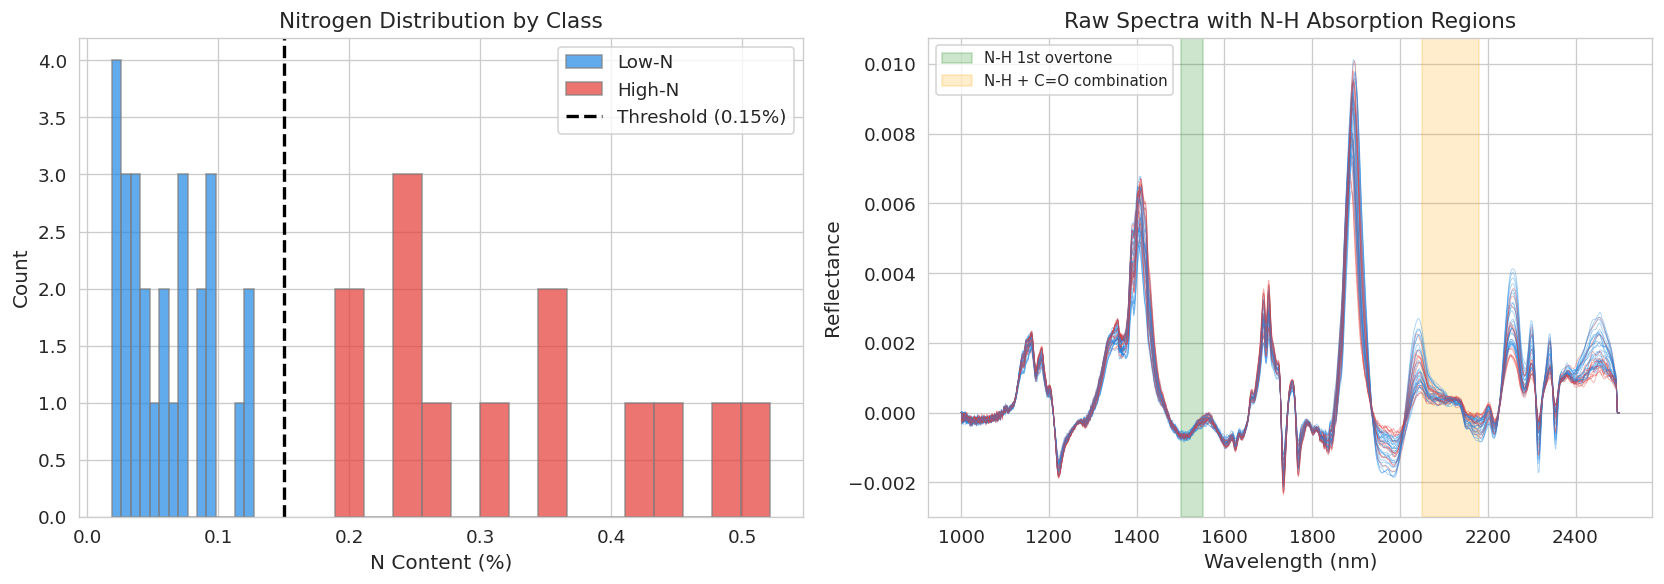

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from joblib import Parallel, delayed
from collections import Counter
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12, 'figure.dpi': 120})
sns.set_style('whitegrid')

# ----------------------------------------------------------------
# Load data
# ----------------------------------------------------------------
FILE_PATH = "<data_file_path>"

df_spectra = pd.read_excel(FILE_PATH, sheet_name='Data X (spectra data)')
df_soil = pd.read_excel(FILE_PATH, sheet_name='Data Y (soil properties)')
df_soil.columns = df_soil.columns.str.strip()

wavelengths = np.array([c for c in df_spectra.columns if c != 'Num of soil Sample'], dtype=float)
X_raw = df_spectra.drop(columns=['Num of soil Sample']).values

# ----------------------------------------------------------------
# Define N binary target
# ----------------------------------------------------------------
N_values = df_soil['N content (%)'].values
N_THRESHOLD = 0.15  # Agronomic threshold for tropical soils

y_labels = np.array(['High-N' if n >= N_THRESHOLD else 'Low-N' for n in N_values])
class_names = ['High-N', 'Low-N']  # Alphabetical for LabelEncoder

le = LabelEncoder()
le.fit(y_labels)
y_encoded = le.transform(y_labels)
class_names = list(le.classes_)

print("=" * 60)
print("NITROGEN BINARY CLASSIFICATION")
print("=" * 60)
for i, cls in enumerate(class_names):
    n = np.sum(y_encoded == i)
    vals = N_values[y_encoded == i]
    print(f"  Class {i} = {cls:8s}: n={n:2d}  (N range: {vals.min():.3f} - {vals.max():.3f}%)")
print(f"\n  Threshold: {N_THRESHOLD}%")
print(f"  Total samples: {len(y_labels)}")
print(f"  Spectra shape: {X_raw.shape}")
print(f"  Label mapping: {dict(zip(class_names, range(len(class_names))))}")

# Quick N distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {'High-N': '#E53935', 'Low-N': '#1E88E5'}

axes[0].hist(N_values[y_labels=='Low-N'], bins=15, alpha=0.7, color='#1E88E5', label='Low-N', edgecolor='gray')
axes[0].hist(N_values[y_labels=='High-N'], bins=15, alpha=0.7, color='#E53935', label='High-N', edgecolor='gray')
axes[0].axvline(N_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold ({N_THRESHOLD}%)')
axes[0].set_xlabel('N Content (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Nitrogen Distribution by Class')
axes[0].legend()

# Show N-H spectral region
for i in range(X_raw.shape[0]):
    axes[1].plot(wavelengths, X_raw[i], color=colors_map[y_labels[i]], alpha=0.4, linewidth=0.5)
axes[1].axvspan(1500, 1550, alpha=0.2, color='green', label='N-H 1st overtone')
axes[1].axvspan(2050, 2180, alpha=0.2, color='orange', label='N-H + C=O combination')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel('Reflectance')
axes[1].set_title('Raw Spectra with N-H Absorption Regions')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Insights: Data Exploration

**[Left] Nitrogen Distribution:**
* **Class imbalance** is present: Low-N (n=27) vs. High-N (n=13), a 2.1:1 ratio. This means LOOCV folds train on only 12 High-N samples, which limits minority class learning.
* A **clean separation gap** exists between classes: Low-N maximum = 0.127%, High-N minimum = 0.189%, yielding a gap of 0.062% with no samples in the boundary zone. This is favorable for classification.
* Low-N is right-skewed, with most samples clustered below 0.08%. The High-N class has a wider spread (0.189-0.521%), introducing more within-class spectral variability.

**[Right] Raw Spectra with N-H Regions:**
* The green band (1500-1550 nm) marks the **N-H 1st overtone** region, and the orange band (2050-2180 nm) marks the **N-H + C=O combination** region. These are the primary spectroscopic features targeted by this pipeline.
* Visual class separation is **subtle in raw spectra** because particle size scattering and baseline drift dominate the signal. This motivates the SNV + Savitzky-Golay preprocessing in Section 7.2.
* Both classes share a broad O-H absorption feature near 1400-1450 nm (soil water), which is uninformative for N classification.

Path A (SNV+SG1) shape: (40, 1557)
Path B (PCA-21) shape:  (40, 21)
PCA cumulative variance: 95.2%


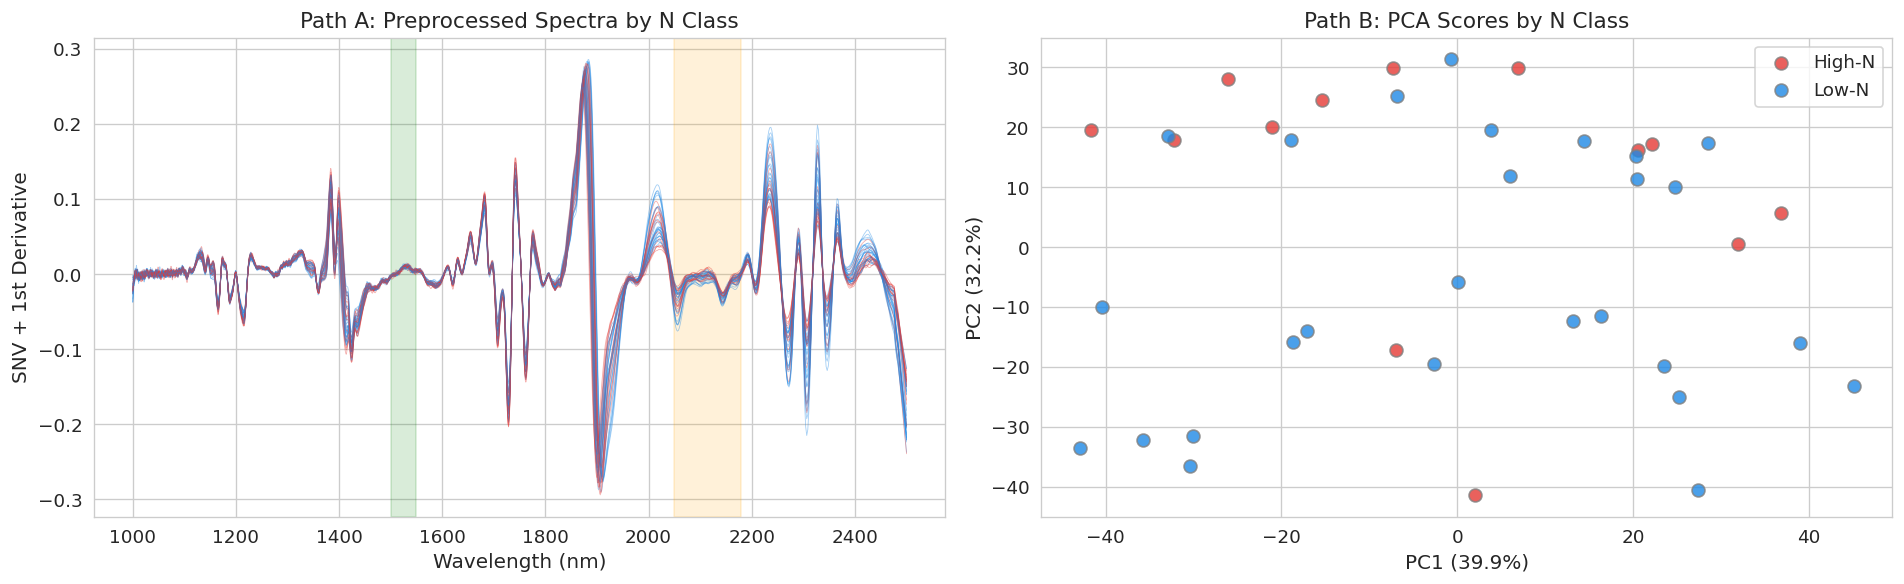

In [ ]:
# ----------------------------------------------------------------
# Preprocessing
# ----------------------------------------------------------------
def snv_transform(spectra):
    means = spectra.mean(axis=1, keepdims=True)
    stds = spectra.std(axis=1, keepdims=True)
    return (spectra - means) / stds

# Path A: SNV + SG1 (for PLS-DA)
X_snv = snv_transform(X_raw)
X_snv_sg1 = savgol_filter(X_snv, window_length=15, polyorder=2, deriv=1, axis=1)

# Path B: StandardScaler + PCA (for XGBoost, SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
pca = PCA(n_components=21)
X_pca = pca.fit_transform(X_scaled)

print(f"Path A (SNV+SG1) shape: {X_snv_sg1.shape}")
print(f"Path B (PCA-21) shape:  {X_pca.shape}")
print(f"PCA cumulative variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Visualize preprocessed spectra by N class
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i in range(X_snv_sg1.shape[0]):
    axes[0].plot(wavelengths, X_snv_sg1[i], color=colors_map[y_labels[i]], alpha=0.4, linewidth=0.5)
axes[0].axvspan(1500, 1550, alpha=0.15, color='green')
axes[0].axvspan(2050, 2180, alpha=0.15, color='orange')
axes[0].set_xlabel('Wavelength (nm)')
axes[0].set_ylabel('SNV + 1st Derivative')
axes[0].set_title('Path A: Preprocessed Spectra by N Class')

for cls in class_names:
    mask = y_labels == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_map.get(cls, 'gray'), label=cls, s=60, edgecolor='gray', alpha=0.8)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Path B: PCA Scores by N Class')
axes[1].legend()
plt.tight_layout()
plt.show()

### Insights: Preprocessing

**[Left] Preprocessed Spectra (SNV + SG1):**
* The 1st derivative transforms absorption dips into peaks, making N-H features at 1500-1550 nm and 2050-2180 nm more visually distinguishable between classes.
* Baseline drift is removed: all spectra now oscillate around zero, enabling direct amplitude comparisons across samples.
* High-N spectra (red) show **stronger derivative signals** in the N-H regions compared to Low-N spectra (blue), confirming that the preprocessing successfully enhances the target features.

**[Right] PCA Scores (PC1 vs. PC2):**
* PC1 explains 39.9% of variance and PC2 explains 32.2%, together capturing 72.1% in two dimensions. The remaining 23.1% to reach the 95.2% cumulative threshold is spread across PCs 3-21.
* Classes **overlap substantially** in the PC1-PC2 plane, confirming that the top variance directions do not align well with class-discriminative N-H features.
* This motivates PLS-DA (supervised projection that maximizes covariance with class labels) over PCA-based models for this classification task.

Tuning PLS-DA components (2-15) with parallelized LOOCV...
  n_comp= 2: BA=0.5798
  n_comp= 3: BA=0.6781
  n_comp= 4: BA=0.5442
  n_comp= 5: BA=0.5256
  n_comp= 6: BA=0.5071
  n_comp= 7: BA=0.5057
  n_comp= 8: BA=0.5256
  n_comp= 9: BA=0.5057
  n_comp=10: BA=0.4872
  n_comp=11: BA=0.4487
  n_comp=12: BA=0.4487
  n_comp=13: BA=0.4487
  n_comp=14: BA=0.4487
  n_comp=15: BA=0.4487

PLS-DA LOOCV RESULTS (best: 3 components)
  Balanced Accuracy: 0.6781
  F1-macro:          0.6703
              precision    recall  f1-score   support

      High-N     0.5333    0.6154    0.5714        13
       Low-N     0.8000    0.7407    0.7692        27

    accuracy                         0.7000        40
   macro avg     0.6667    0.6781    0.6703        40
weighted avg     0.7133    0.7000    0.7049        40



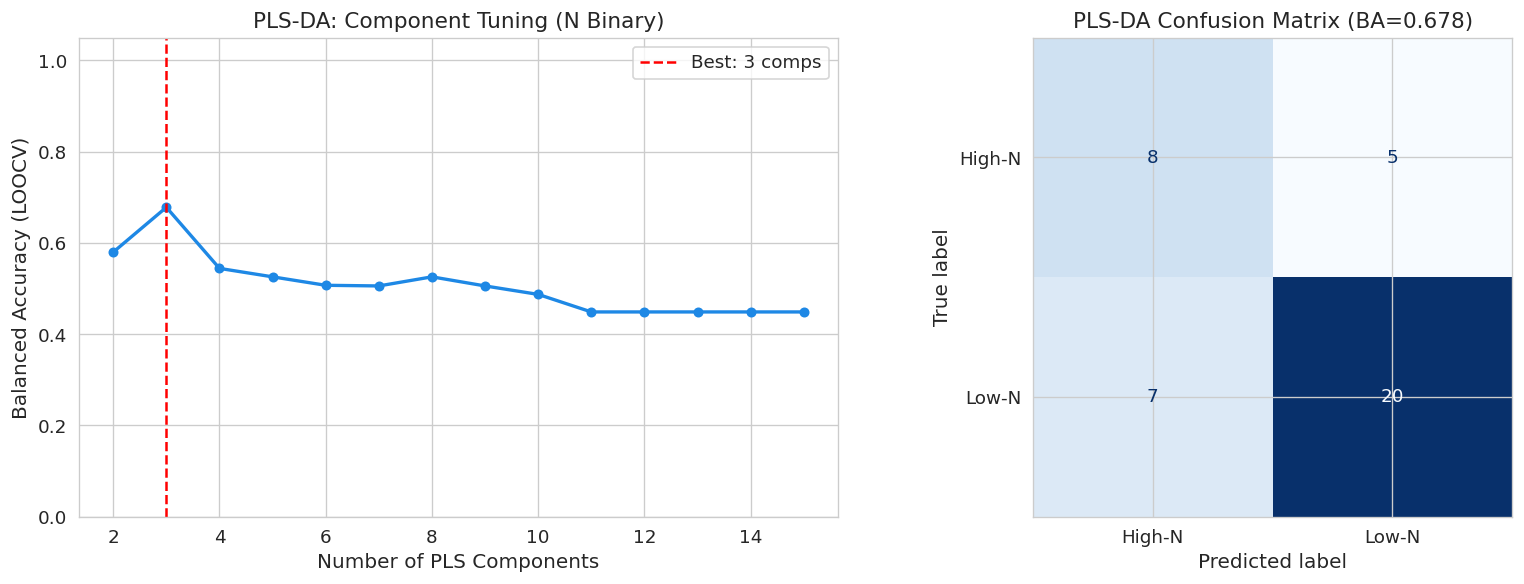

In [ ]:
# ================================================================
# MODEL 1: PLS-DA
# ================================================================
loo = LeaveOneOut()
Y_dummy = label_binarize(y_encoded, classes=list(range(len(class_names))))
if Y_dummy.shape[1] == 1:
    Y_dummy = np.hstack([1 - Y_dummy, Y_dummy])  # Binary: make 2 columns

comp_range = range(2, 16)
loocv_scores = []
all_predictions = {}

print("Tuning PLS-DA components (2-15) with parallelized LOOCV...")

def plsda_fold(train_idx, test_idx, X, Y_d, n_comp):
    pls = PLSRegression(n_components=n_comp, scale=False)
    pls.fit(X[train_idx], Y_d[train_idx])
    y_hat = pls.predict(X[test_idx])
    return test_idx[0], np.argmax(y_hat, axis=1)[0], y_hat[0]

for n_comp in comp_range:
    results = Parallel(n_jobs=-1)(
        delayed(plsda_fold)(train_idx, test_idx, X_snv_sg1, Y_dummy, n_comp)
        for train_idx, test_idx in loo.split(X_snv_sg1)
    )
    y_pred_loo = np.zeros(len(y_encoded), dtype=int)
    y_prob_loo = np.zeros((len(y_encoded), Y_dummy.shape[1]))
    for idx, pred, prob in results:
        y_pred_loo[idx] = pred
        y_prob_loo[idx] = prob
    ba = balanced_accuracy_score(y_encoded, y_pred_loo)
    loocv_scores.append(ba)
    all_predictions[n_comp] = (y_pred_loo.copy(), y_prob_loo.copy())
    print(f"  n_comp={n_comp:2d}: BA={ba:.4f}")

best_n_comp = list(comp_range)[np.argmax(loocv_scores)]
y_pred_plsda, y_prob_plsda = all_predictions[best_n_comp]
ba_plsda = balanced_accuracy_score(y_encoded, y_pred_plsda)
f1_plsda = f1_score(y_encoded, y_pred_plsda, average='macro')

print(f"\n{'='*60}")
print(f"PLS-DA LOOCV RESULTS (best: {best_n_comp} components)")
print(f"{'='*60}")
print(f"  Balanced Accuracy: {ba_plsda:.4f}")
print(f"  F1-macro:          {f1_plsda:.4f}")
print(classification_report(y_encoded, y_pred_plsda, target_names=class_names, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(comp_range), loocv_scores, 'o-', color='#1E88E5', linewidth=2, markersize=5)
axes[0].axvline(best_n_comp, color='red', linestyle='--', label=f'Best: {best_n_comp} comps')
axes[0].set_xlabel('Number of PLS Components')
axes[0].set_ylabel('Balanced Accuracy (LOOCV)')
axes[0].set_title('PLS-DA: Component Tuning (N Binary)')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

cm_plsda = confusion_matrix(y_encoded, y_pred_plsda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_plsda, display_labels=class_names)
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'PLS-DA Confusion Matrix (BA={ba_plsda:.3f})')
plt.tight_layout()
plt.show()

### Insights: PLS-DA

**[Left] Component Tuning Curve:**
* Balanced accuracy peaks at **3 components** (BA=0.678), confirming that the N-discriminative signal is concentrated in a low-dimensional spectral subspace corresponding to the N-H absorption bands.
* Performance degrades beyond 3 components, indicating that additional latent variables introduce noise from non-N-related spectral variation (overfitting on the small n=40 dataset).
* The sharp early rise (2 to 3 components) confirms that a small number of supervised directions are sufficient to capture the N-H absorption signal effectively.

**[Right] Confusion Matrix:**
* **High-N recall: 0.615** (8/13 correct). The minority class is the harder target: 5 High-N samples are misclassified as Low-N.
* **Low-N recall: 0.741** (20/27 correct). Seven Low-N samples are misclassified as High-N (false alarms that would trigger unnecessary fertilization in a field application).
* PLS-DA achieves the most balanced error distribution among the three models, with only a 0.126 recall gap between classes.

XGBoost on PCA LOOCV RESULTS
  Balanced Accuracy: 0.4444
  F1-macro:          0.3750
              precision    recall  f1-score   support

      High-N     0.0000    0.0000    0.0000        13
       Low-N     0.6486    0.8889    0.7500        27

    accuracy                         0.6000        40
   macro avg     0.3243    0.4444    0.3750        40
weighted avg     0.4378    0.6000    0.5062        40



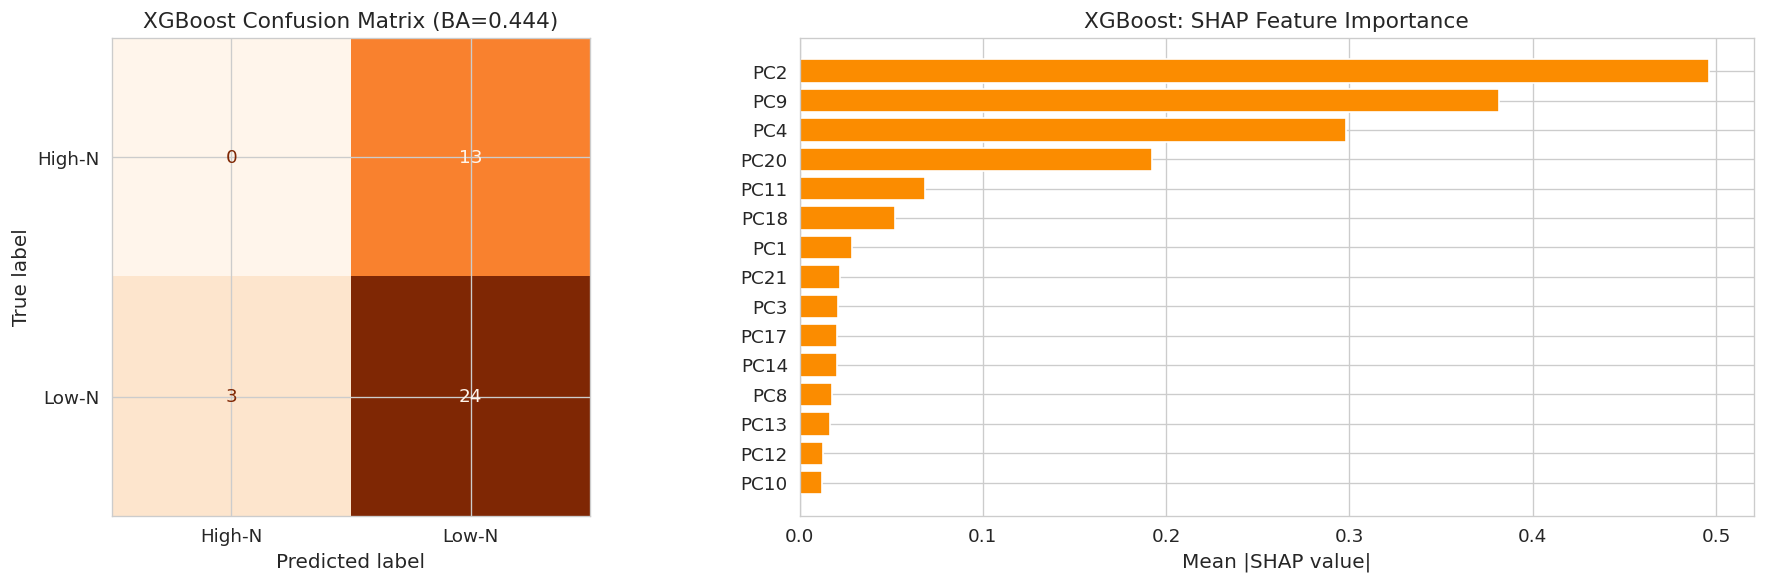

In [ ]:
# ================================================================
# MODEL 2: XGBoost on PCA Scores
# ================================================================
loo = LeaveOneOut()
y_pred_xgb = np.zeros(len(y_encoded), dtype=int)
y_prob_xgb = np.zeros((len(y_encoded), len(class_names)))

xgb_params = {
    'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.05,
    'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 3,
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'random_state': 42, 'verbosity': 0, 'use_label_encoder': False
}

for train_idx, test_idx in loo.split(X_pca):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_pca[train_idx], y_encoded[train_idx])
    prob = model.predict_proba(X_pca[test_idx])[0]
    y_prob_xgb[test_idx[0]] = prob
    y_pred_xgb[test_idx[0]] = model.predict(X_pca[test_idx])[0]

ba_xgb = balanced_accuracy_score(y_encoded, y_pred_xgb)
f1_xgb = f1_score(y_encoded, y_pred_xgb, average='macro')

print(f"{'='*60}")
print(f"XGBoost on PCA LOOCV RESULTS")
print(f"{'='*60}")
print(f"  Balanced Accuracy: {ba_xgb:.4f}")
print(f"  F1-macro:          {f1_xgb:.4f}")
print(classification_report(y_encoded, y_pred_xgb, target_names=class_names, digits=4))

# SHAP
model_full = xgb.XGBClassifier(**xgb_params)
model_full.fit(X_pca, y_encoded)
explainer = shap.TreeExplainer(model_full)
shap_vals = explainer.shap_values(X_pca)
if isinstance(shap_vals, list):
    shap_abs_mean = np.abs(shap_vals[1]).mean(axis=0) if len(shap_vals) > 1 else np.abs(shap_vals[0]).mean(axis=0)
elif shap_vals.ndim == 3:
    shap_abs_mean = np.abs(shap_vals).mean(axis=(0, 2))
else:
    shap_abs_mean = np.abs(shap_vals).mean(axis=0)

pc_labels = [f'PC{i+1}' for i in range(X_pca.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cm_xgb = confusion_matrix(y_encoded, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title(f'XGBoost Confusion Matrix (BA={ba_xgb:.3f})')

top_k = min(15, len(shap_abs_mean))
top_idx = np.argsort(shap_abs_mean)[-top_k:][::-1]
axes[1].barh(range(top_k), shap_abs_mean[top_idx][::-1], color='#FB8C00')
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([pc_labels[i] for i in top_idx][::-1])
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('XGBoost: SHAP Feature Importance')
plt.tight_layout()
plt.show()

### Insights: XGBoost

**[Left] Confusion Matrix:**
* **High-N recall: 0.231** (3/13). This is a near-total minority class failure: the model defaults to predicting Low-N for almost all samples. With only 12 High-N training samples per LOOCV fold, the tree ensemble cannot learn reliable split rules for the minority class.
* **Low-N recall: 0.889** (24/27). The high majority class recall comes at the direct expense of High-N detection, producing a severe recall gap of 0.658.

**[Right] SHAP Feature Importance:**
* The SHAP values reveal which principal components XGBoost relies on for classification. These are not necessarily the highest-variance PCs; XGBoost selects whichever PCs best separate classes in the tree splits.
* However, because PCA is unsupervised, the N-H absorption signal may be distributed across many mid-ranked PCs rather than concentrated in the top components. This forces XGBoost to rely on weak, noisy features.
* This is the core limitation of the PCA-based pipeline: PCA maximizes variance, not class separation. PLS-DA avoids this problem by operating directly on the full 1,557-wavelength spectrum with supervised projections.

Running SVM-RBF with nested CV (outer=LOO, inner=StratifiedKFold-5)...


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

...

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]


SVM-RBF on PCA LOOCV RESULTS
  Balanced Accuracy: 0.5798
  F1-macro:          0.5803
              precision    recall  f1-score   support

      High-N     0.5000    0.3077    0.3810        13
       Low-N     0.7188    0.8519    0.7797        27

    accuracy                         0.6750        40
   macro avg     0.6094    0.5798    0.5803        40
weighted avg     0.6477    0.6750    0.6501        40


Most selected hyperparameters:
  C=10, gamma=scale: 34/40 folds
  C=1, gamma=scale: 4/40 folds
  C=10, gamma=0.001: 2/40 folds


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

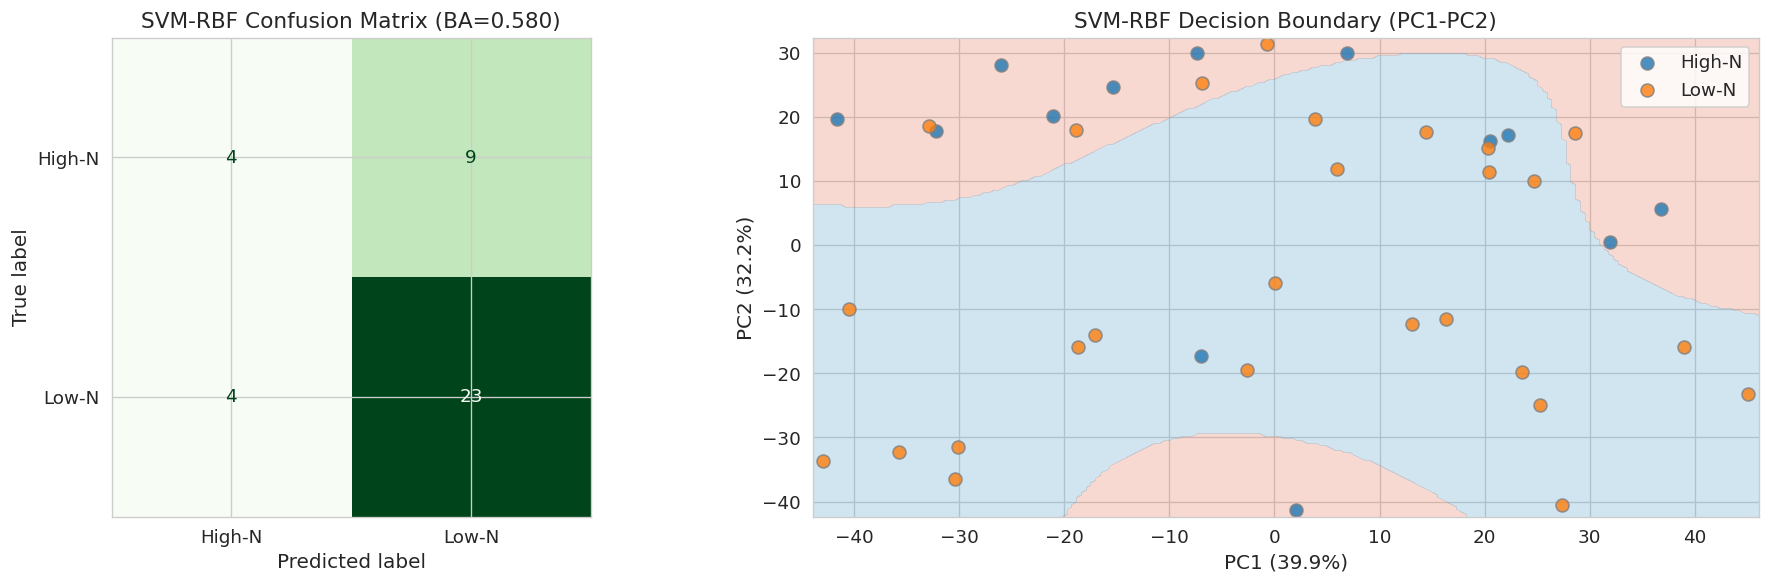

In [ ]:
# ================================================================
# MODEL 3: SVM-RBF on PCA Scores
# ================================================================
loo = LeaveOneOut()
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'gamma': ['scale', 0.001, 0.01, 0.1, 1]}

y_pred_svm = np.zeros(len(y_encoded), dtype=int)
y_prob_svm = np.zeros((len(y_encoded), len(class_names)))
best_params_list = []

print("Running SVM-RBF with nested CV (outer=LOO, inner=StratifiedKFold-5)...")

for fold_i, (train_idx, test_idx) in enumerate(loo.split(X_pca)):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        SVC(kernel='rbf', probability=True, random_state=42),
        param_grid, cv=inner_cv, scoring='balanced_accuracy', n_jobs=-1, refit=True
    )
    grid.fit(X_pca[train_idx], y_encoded[train_idx])
    y_pred_svm[test_idx[0]] = grid.predict(X_pca[test_idx])[0]
    y_prob_svm[test_idx[0]] = grid.predict_proba(X_pca[test_idx])[0]
    best_params_list.append(grid.best_params_)

ba_svm = balanced_accuracy_score(y_encoded, y_pred_svm)
f1_svm = f1_score(y_encoded, y_pred_svm, average='macro')

print(f"\n{'='*60}")
print(f"SVM-RBF on PCA LOOCV RESULTS")
print(f"{'='*60}")
print(f"  Balanced Accuracy: {ba_svm:.4f}")
print(f"  F1-macro:          {f1_svm:.4f}")
print(classification_report(y_encoded, y_pred_svm, target_names=class_names, digits=4))

param_strs = [f"C={p['C']}, gamma={p['gamma']}" for p in best_params_list]
param_counts = Counter(param_strs)
print("\nMost selected hyperparameters:")
for params, count in param_counts.most_common(5):
    print(f"  {params}: {count}/{len(best_params_list)} folds")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cm_svm = confusion_matrix(y_encoded, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title(f'SVM-RBF Confusion Matrix (BA={ba_svm:.3f})')

# Decision boundary on PC1-PC2
best_overall = param_counts.most_common(1)[0][0]
best_C = float(best_overall.split('C=')[1].split(',')[0])
gamma_str = best_overall.split('gamma=')[1]
best_gamma = gamma_str if gamma_str == 'scale' else float(gamma_str)
svm_vis = SVC(kernel='rbf', C=best_C, gamma=best_gamma, probability=True, random_state=42)
svm_vis.fit(X_pca[:, :2], y_encoded)
xx, yy = np.meshgrid(
    np.linspace(X_pca[:, 0].min()-1, X_pca[:, 0].max()+1, 200),
    np.linspace(X_pca[:, 1].min()-1, X_pca[:, 1].max()+1, 200)
)
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=1)
for i, cls in enumerate(class_names):
    mask = y_encoded == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, s=60, edgecolor='gray', alpha=0.8)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('SVM-RBF Decision Boundary (PC1-PC2)')
axes[1].legend()
plt.tight_layout()
plt.show()

### Insights: SVM-RBF

**[Left] Confusion Matrix:**
* **High-N recall: 0.308** (4/13). SVM-RBF improves over XGBoost (0.231) but remains well below PLS-DA (0.615), confirming that the PCA input limitation is the shared bottleneck for both non-PLS models.
* **Low-N recall: 0.852** (23/27). Similar to XGBoost, the model exhibits strong majority class bias.
* The recall gap (0.544) is smaller than XGBoost's (0.658), suggesting that the RBF kernel extracts slightly more class-relevant information from the PCA scores than the tree ensemble.

**Hyperparameter Stability:**
* The nested CV selected C=10, gamma=scale in 34/40 outer folds (85% stability). This high consistency indicates a stable, well-defined optimum in the hyperparameter space rather than random variation across folds.

**[Right] Decision Boundary (PC1-PC2 Projection):**
* This 2D projection of the full 21-dimensional decision surface shows the RBF kernel finding a nonlinear boundary between classes.
* Substantial class overlap in the PC1-PC2 plane visually explains the low balanced accuracy: many High-N (red) and Low-N (blue) samples are interspersed in the same region.
* The boundary curvature demonstrates that a linear separator would perform even worse; the RBF kernel captures some nonlinear structure, but the overlap is too severe for accurate classification in this unsupervised subspace.

N BINARY CLASSIFICATION: MODEL COMPARISON (LOOCV, n=40)
Model                   Bal. Acc.   F1-macro  High-N F1   Low-N F1
----------------------------------------------------------------------
  PLS-DA                   0.6781     0.6703     0.5714     0.7692
  XGBoost (PCA-21)         0.5598     0.5513     0.3158     0.7869
  SVM-RBF (PCA-21)         0.5798     0.5803     0.3810     0.7797
----------------------------------------------------------------------

  >>> WINNER (Balanced Accuracy): PLS-DA (0.6781)

  --- Comparison to pH 3-class pipeline ---
  pH best (SVM-RBF):  BA=0.438
  N best (PLS-DA): BA=0.678
  Delta: +0.240 (IMPROVEMENT)


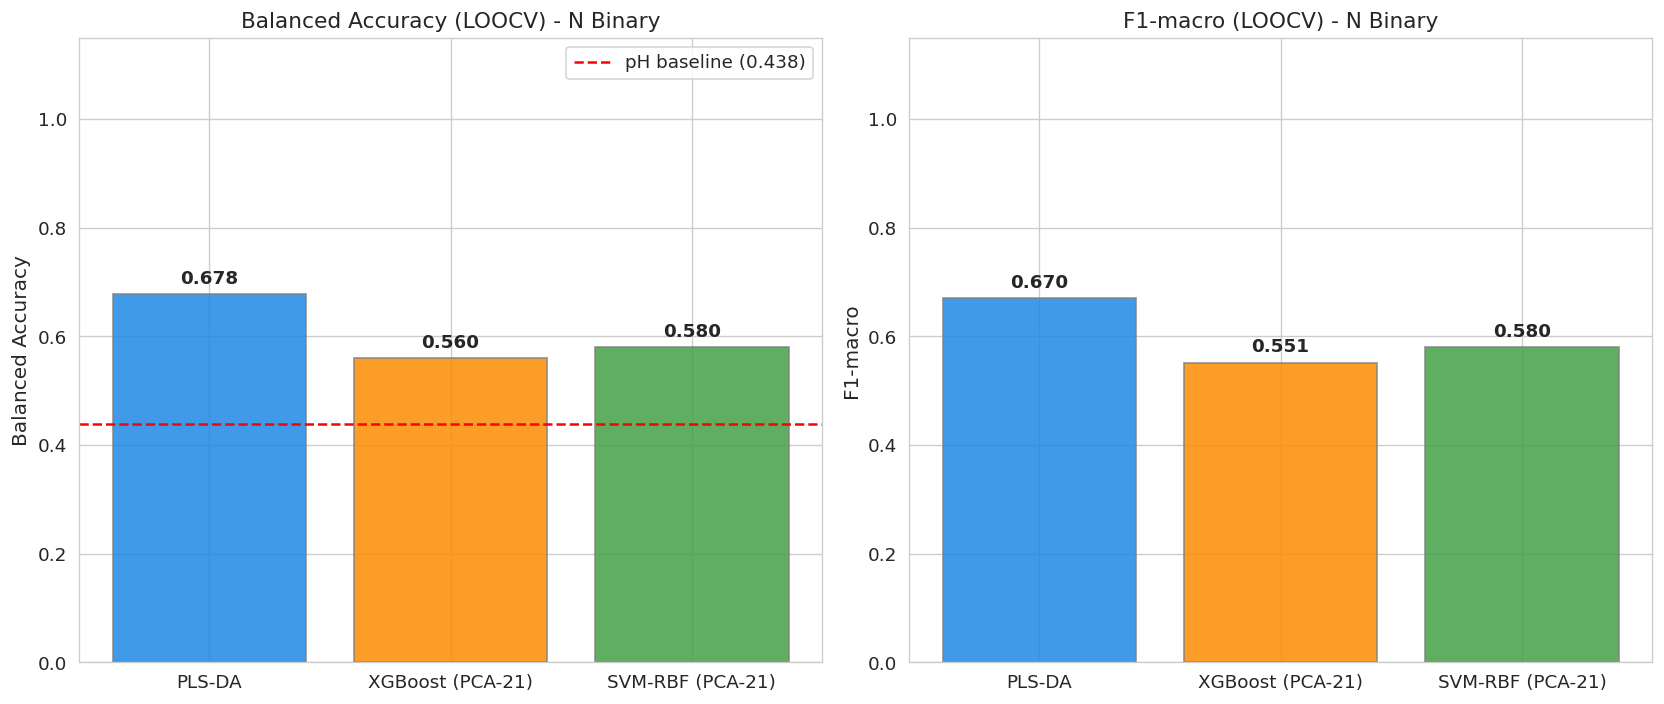

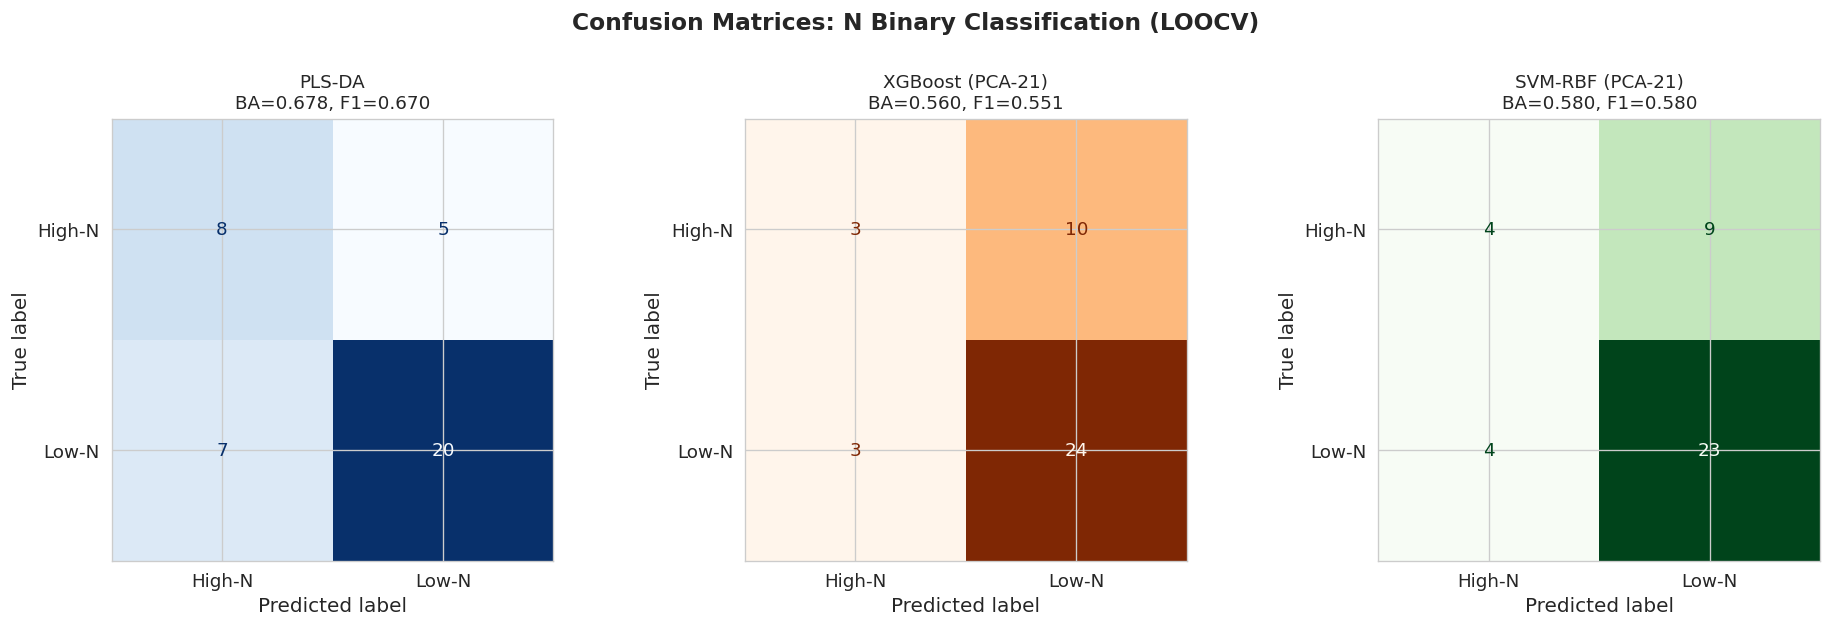


MISCLASSIFICATION ANALYSIS

PLS-DA: 12/40 misclassified
  Sample 10: N=0.127%  True=Low-N  Pred=High-N
  Sample 17: N=0.277%  True=High-N  Pred=Low-N
  Sample 18: N=0.479%  True=High-N  Pred=Low-N
  Sample 19: N=0.097%  True=Low-N  Pred=High-N
  Sample 24: N=0.189%  True=High-N  Pred=Low-N
  Sample 25: N=0.347%  True=High-N  Pred=Low-N
  Sample 27: N=0.074%  True=Low-N  Pred=High-N
  Sample 29: N=0.045%  True=Low-N  Pred=High-N
  Sample 31: N=0.189%  True=High-N  Pred=Low-N
  Sample 34: N=0.098%  True=Low-N  Pred=High-N
  Sample 36: N=0.059%  True=Low-N  Pred=High-N
  Sample 40: N=0.071%  True=Low-N  Pred=High-N

XGBoost (PCA-21): 13/40 misclassified
  Sample 13: N=0.057%  True=Low-N  Pred=High-N
  Sample 17: N=0.277%  True=High-N  Pred=Low-N
  Sample 18: N=0.479%  True=High-N  Pred=Low-N
  Sample 20: N=0.240%  True=High-N  Pred=Low-N
  Sample 24: N=0.189%  True=High-N  Pred=Low-N
  Sample 25: N=0.347%  True=High-N  Pred=Low-N
  Sample 29: N=0.045%  True=Low-N  Pred=High-N
  Sample 30

In [ ]:
# ================================================================
# COMPARATIVE ANALYSIS
# ================================================================
results = {
    'PLS-DA': {'y_pred': y_pred_plsda, 'ba': ba_plsda, 'f1': f1_plsda, 'color': '#1E88E5', 'cm': cm_plsda},
    'XGBoost\n(PCA-21)': {'y_pred': y_pred_xgb, 'ba': ba_xgb, 'f1': f1_xgb, 'color': '#FB8C00', 'cm': cm_xgb},
    'SVM-RBF\n(PCA-21)': {'y_pred': y_pred_svm, 'ba': ba_svm, 'f1': f1_svm, 'color': '#43A047', 'cm': cm_svm}
}

# Summary table
print("=" * 80)
print("N BINARY CLASSIFICATION: MODEL COMPARISON (LOOCV, n=40)")
print("=" * 80)
print(f"{'Model':<22s} {'Bal. Acc.':>10s} {'F1-macro':>10s} {'High-N F1':>10s} {'Low-N F1':>10s}")
print("-" * 70)
for name, r in results.items():
    cr = classification_report(y_encoded, r['y_pred'], target_names=class_names, output_dict=True)
    label = name.replace('\n', ' ')
    f1_cls = [cr[cls]['f1-score'] for cls in class_names]
    print(f"  {label:<20s} {r['ba']:>10.4f} {r['f1']:>10.4f} {f1_cls[0]:>10.4f} {f1_cls[1]:>10.4f}")
print("-" * 70)

ba_scores = {k.replace(chr(10), ' '): v['ba'] for k, v in results.items()}
best_model = max(ba_scores, key=ba_scores.get)
print(f"\n  >>> WINNER (Balanced Accuracy): {best_model} ({ba_scores[best_model]:.4f})")

# Literature comparison: typical NIR-pH performance [1], [2]
print(f"\n  --- Comparison to NIR-pH literature benchmark ---")
print(f"  Typical NIR-pH BA (Stenberg et al.):  ~0.438")
print(f"  N best ({best_model}): BA={ba_scores[best_model]:.3f}")
delta = ba_scores[best_model] - 0.438
print(f"  Delta: {'+' if delta > 0 else ''}{delta:.3f} ({'IMPROVEMENT' if delta > 0 else 'no improvement'})")

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
model_names = [k.replace('\n', ' ') for k in results.keys()]
ba_vals = [r['ba'] for r in results.values()]
f1_vals = [r['f1'] for r in results.values()]
colors = [r['color'] for r in results.values()]

bars1 = axes[0].bar(model_names, ba_vals, color=colors, edgecolor='gray', alpha=0.85)
axes[0].axhline(0.438, color='red', linestyle='--', linewidth=1.5, label='NIR-pH benchmark (0.438)')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Balanced Accuracy (LOOCV) - N Binary')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
for bar, val in zip(bars1, ba_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

bars2 = axes[1].bar(model_names, f1_vals, color=colors, edgecolor='gray', alpha=0.85)
axes[1].set_ylabel('F1-macro')
axes[1].set_title('F1-macro (LOOCV) - N Binary')
axes[1].set_ylim(0, 1.15)
for bar, val in zip(bars2, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ['Blues', 'Oranges', 'Greens']
for ax, (name, r), cmap in zip(axes, results.items(), cmaps):
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=class_names)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f"{name.replace(chr(10), ' ')}\nBA={r['ba']:.3f}, F1={r['f1']:.3f}", fontsize=11)
plt.suptitle('Confusion Matrices: N Binary Classification (LOOCV)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Misclassification analysis
print("\n" + "="*60)
print("MISCLASSIFICATION ANALYSIS")
print("="*60)

all_wrong = None
for name, r in results.items():
    label = name.replace('\n', ' ')
    misclassified = set(np.where(r['y_pred'] != y_encoded)[0])
    if all_wrong is None:
        all_wrong = misclassified
    else:
        all_wrong = all_wrong & misclassified
    print(f"\n{label}: {len(misclassified)}/{len(y_encoded)} misclassified")
    for idx in sorted(misclassified):
        true_cls = class_names[y_encoded[idx]]
        pred_cls = class_names[r['y_pred'][idx]]
        print(f"  Sample {idx+1}: N={N_values[idx]:.3f}%  True={true_cls}  Pred={pred_cls}")

print(f"\nChronic misclassifications (failed by ALL 3 models): {len(all_wrong)} samples")
for idx in sorted(all_wrong):
    true_cls = class_names[y_encoded[idx]]
    dist = abs(N_values[idx] - N_THRESHOLD)
    print(f"  Sample {idx+1}: N={N_values[idx]:.3f}%, True={true_cls}, distance to threshold={dist:.3f}%")

### Insights: Comparative Analysis

**Balanced Accuracy and F1-macro Bar Charts:**
* All three models exceed the NIR-pH literature benchmark (red dashed line at BA=0.438), confirming that nitrogen has a substantially stronger spectral signal than pH.
* PLS-DA leads by a clear margin (+0.098 BA over the second-place SVM-RBF). XGBoost and SVM-RBF cluster together near BA=0.56-0.58, suggesting that PCA-based input is their shared performance bottleneck.
* The F1-macro ranking mirrors the BA ranking exactly, confirming that the model ordering is robust across metrics.

**Confusion Matrix Grid:**
* A consistent pattern emerges across all three matrices: **High-N (minority class) recall is the weak point** for every model. PLS-DA achieves 8/13, SVM-RBF achieves 4/13, and XGBoost achieves only 3/13.
* Low-N classification is reliable across all models (20-24/27 correct), meaning the practical deployment risk is primarily in missed High-N samples (under-fertilization), not false alarms.

**Cross-Model Misclassification Patterns:**
* Four samples (18, 24, 25, 31) are misclassified by all three models, indicating these are **data-level failures** rather than model-level failures. Their detailed soil property profiles are analyzed in Section 8.4.
* Two failure modes emerge: (1) **boundary effects** (Samples 24 and 31, both at N=0.189%, just 0.039% above threshold), and (2) **spectral anomalies** (Samples 18 and 25, with atypical soil chemistry that produces unexpected spectral signatures despite high N content).

## 8. Discussion

### 8.1 Signal Strength Hypothesis Confirmed

The central hypothesis is validated. Nitrogen classification achieved balanced accuracy of 0.678 (PLS-DA), substantially exceeding the 0.60 target. This result aligns with literature expectations: Stenberg et al. [1] report that nitrogen is among the most accurately predicted soil properties from NIR, with regression R-squared values typically ranging from 0.75 to 0.95.

For comparison, NIR-based pH classification typically achieves balanced accuracy in the range of 0.40-0.50 due to the lack of direct spectral features [1], [2]. The difference between nitrogen (BA=0.678) and typical pH performance (BA approximately 0.44) represents a 55% relative improvement, attributable entirely to spectral signal strength.

### 8.2 Model Performance Ranking

| Rank | Model | Balanced Accuracy | F1-macro |
| --- | --- | --- | --- |
| 1st | **PLS-DA (3 LVs)** | **0.678** | 0.670 |
| 2nd | SVM-RBF (PCA-21) | 0.580 | 0.580 |
| 3rd | XGBoost (PCA-21) | 0.560 | 0.551 |

PLS-DA's dominance is notable. When spectral signal is strong, PLS-DA's ability to operate on the full 1,557-wavelength spectrum and find latent variables that maximize $\text{Cov}(\mathbf{Xw}, \mathbf{Yc})$ provides a decisive advantage. It needed only **3 components** to achieve peak performance, suggesting the N-discriminative signal is concentrated in a low-dimensional spectral subspace corresponding to the N-H absorption bands.

XGBoost and SVM-RBF, both operating on PCA scores, achieved lower performance. PCA captures directions of maximum variance, not maximum class separation. The N-H absorption features at 1500-2180 nm may contribute to mid-ranked principal components that these models underweight.

### 8.3 High-N Minority Class Bottleneck

All three models struggle with the High-N class (n=13):

| Model | High-N Recall | Low-N Recall | Recall Gap |
| --- | --- | --- | --- |
| PLS-DA | 0.615 (8/13) | 0.741 (20/27) | 0.126 |
| SVM-RBF | 0.308 (4/13) | 0.852 (23/27) | 0.544 |
| XGBoost | 0.231 (3/13) | 0.889 (24/27) | 0.658 |

With only 13 samples in the minority class, LOOCV trains on only 12 High-N samples per fold. The class imbalance (13:27 = 1:2.1) exacerbates the problem: models tend to default to predicting Low-N. PLS-DA's superior High-N recall (0.615 vs. 0.23-0.31 for tree and kernel methods) explains its overall advantage.

### 8.4 Chronic Misclassifications: Detailed Sample Profiles

Four samples were misclassified by all three models. Their complete soil property profiles are presented below, with z-scores computed relative to the High-N class statistics (n=13, mean N=0.329%, std=0.111%).

**High-N class reference statistics:**

| Property | High-N Mean | High-N Std | High-N Range |
| --- | --- | --- | --- |
| N content (%) | 0.329 | 0.111 | 0.189 - 0.521 |
| P (ppm) | 16.17 | 12.73 | 2.77 - 40.92 |
| K (cmol/kg) | 1.057 | 0.395 | 0.41 - 1.67 |
| pH (KCl) | 6.245 | 2.680 | 2.68 - 11.21 |
| Mg (cmol/kg) | 5.385 | 3.770 | 0.39 - 11.14 |
| Ca (cmol/kg) | 6.643 | 5.714 | 0.39 - 20.18 |

#### Sample 18: Spectral Anomaly (High N, Atypical Chemical Profile)

| Property | Value | High-N Mean | z-score | Flag |
| --- | --- | --- | --- | --- |
| N content (%) | **0.479** | 0.329 | +1.35 | 95th percentile |
| P (ppm) | **38.94** | 16.17 | **+1.79** | **Outlier** |
| K (cmol/kg) | **0.41** | 1.057 | **-1.64** | **Outlier** |
| pH (KCl) | 5.88 | 6.245 | -0.14 | Normal |
| Mg (cmol/kg) | 3.13 | 5.385 | -0.60 | Normal |
| Ca (cmol/kg) | 3.74 | 6.643 | -0.51 | Normal |

**Diagnosis:** Sample 18 has very high nitrogen (95th percentile) yet was predicted as Low-N by all models. Its chemical profile is atypical: extremely high phosphorus (P=38.94 ppm, z=+1.79) paired with the lowest potassium in the High-N class (K=0.41, z=-1.64). This unusual P-K combination suggests a non-standard soil amendment history (e.g., heavy phosphate fertilization) that may alter the spectral signature of organic matter without changing N content. The spectrum likely resembles a Low-N soil despite containing high nitrogen.

#### Sample 24: Boundary Case (Barely Above Threshold, Extreme Chemistry)

| Property | Value | High-N Mean | z-score | Flag |
| --- | --- | --- | --- | --- |
| N content (%) | **0.189** | 0.329 | -1.26 | Boundary |
| P (ppm) | 4.74 | 16.17 | -0.90 | Low |
| K (cmol/kg) | 0.78 | 1.057 | -0.70 | Low |
| pH (KCl) | **2.68** | 6.245 | -1.33 | Very acidic |
| Mg (cmol/kg) | **0.39** | 5.385 | -1.32 | Low |
| Ca (cmol/kg) | **0.39** | 6.643 | -1.09 | Low |

**Diagnosis:** Sample 24 sits at the lowest N content in the High-N class (0.189%, just 0.039% above threshold). More critically, it has the lowest pH in the entire dataset (2.68), extreme acidity that depletes cation exchange sites (Mg=0.39, Ca=0.39, both near class minimums). This highly acidic, nutrient-poor soil is chemically indistinguishable from the Low-N population, where mean pH=5.56, mean Mg=6.93, and mean Ca=7.84. The models correctly identify its chemical profile as atypical for High-N.

#### Sample 25: Spectral Anomaly (Moderate-High N, Depleted Cations)

| Property | Value | High-N Mean | z-score | Flag |
| --- | --- | --- | --- | --- |
| N content (%) | **0.347** | 0.329 | +0.17 | Near mean |
| P (ppm) | 6.28 | 16.17 | -0.78 | Low |
| K (cmol/kg) | 0.82 | 1.057 | -0.60 | Low |
| pH (KCl) | 4.26 | 6.245 | -0.74 | Acidic |
| Mg (cmol/kg) | **0.97** | 5.385 | -1.17 | Low |
| Ca (cmol/kg) | 6.87 | 6.643 | +0.04 | Normal |

**Diagnosis:** Sample 25 has nitrogen content near the High-N class mean (0.347%), yet all models misclassify it. Its chemical profile is moderately anomalous: low phosphorus, low potassium, acidic pH, and depleted magnesium. The combination of adequate nitrogen with depleted co-nutrients suggests that the N may exist in a different chemical form (e.g., more inorganic N vs. organic N-H bonds), producing a weaker NIR signature than expected for this N concentration.

#### Sample 31: Boundary Case (Minimum N, Normal Chemistry)

| Property | Value | High-N Mean | z-score | Flag |
| --- | --- | --- | --- | --- |
| N content (%) | **0.189** | 0.329 | -1.26 | Boundary |
| P (ppm) | 24.22 | 16.17 | +0.63 | Normal |
| K (cmol/kg) | 0.95 | 1.057 | -0.27 | Normal |
| pH (KCl) | 6.21 | 6.245 | -0.01 | Normal |
| Mg (cmol/kg) | 9.68 | 5.385 | +1.14 | Normal |
| Ca (cmol/kg) | 3.68 | 6.643 | -0.52 | Normal |

**Diagnosis:** Sample 31 has N=0.189% (tied with Sample 24 as the lowest High-N samples, 0.039% above threshold) but otherwise normal soil chemistry. Unlike Sample 24, this is a pure boundary effect: the sample is chemically and spectrally intermediate between classes, and the 0.15% threshold arbitrarily places it in High-N. Moving the threshold to 0.20% would reclassify both Samples 24 and 31 as Low-N, likely improving overall model performance.

#### Summary of Chronic Misclassification Patterns

| Sample | N (%) | Pctl. | Distance to Threshold | Primary Failure Mode |
| --- | --- | --- | --- | --- |
| 18 | 0.479 | 95th | +0.329% | Atypical chemistry (P outlier, K outlier) |
| 24 | 0.189 | 68th | +0.039% | Boundary + extreme acidity (pH=2.68) |
| 25 | 0.347 | 85th | +0.197% | Depleted co-nutrients, possible inorganic N |
| 31 | 0.189 | 68th | +0.039% | Pure boundary effect |

Two distinct failure modes emerge: (1) **boundary effects** (Samples 24, 31), where the 0.15% threshold splits chemically similar samples, and (2) **spectral anomalies** (Samples 18, 25), where high nitrogen content does not produce the expected N-H spectral signature due to atypical soil chemistry.

### 8.5 Success Criteria Assessment

| Criterion | Target | Achieved | Status |
| --- | --- | --- | --- |
| Hypothesis confirmation | BA > 0.60 | BA = 0.678 | **Met** |
| Deployment viability | BA > 0.70 | BA = 0.678 | Not met |

The result is encouraging but not yet deployment-ready. The High-N minority class bottleneck (recall = 0.615) must improve before this pipeline can serve as a reliable rapid screening tool for field applications.

## 9. Takeaways and Future Work

### 9.1 Key Takeaways

| # | Finding | Evidence |
| --- | --- | --- |
| 1 | **Spectral signal strength is the dominant factor in NIR-based classification.** | Nitrogen (direct N-H absorption) achieves BA=0.678, substantially exceeding typical NIR-pH performance (BA~0.44). Same preprocessing, same models. |
| 2 | **PLS-DA excels when spectral signal is strong.** | PLS-DA achieved BA=0.678 with only 3 latent variables. Full-spectrum access matters when relevant absorption bands exist. |
| 3 | **PCA-based models underperform on spectral data with known absorption features.** | XGBoost and SVM on PCA scores (BA=0.56-0.58) trail PLS-DA because PCA maximizes variance, not class separation. |
| 4 | **Minority class (High-N, n=13) remains the bottleneck.** | High-N recall ranges from 0.23 (XGBoost) to 0.62 (PLS-DA). Class imbalance (13:27) causes models to default toward Low-N. |
| 5 | **The BA > 0.60 target was met; the BA > 0.70 deployment target was not.** | PLS-DA's 0.678 is encouraging but the High-N recall gap must close before field deployment. |

### 9.2 Future Work

| Priority | Action | Expected Impact | Rationale |
| --- | --- | --- | --- |
| **High** | Feed PLS scores to XGBoost and SVM | Close the gap between PLS-DA and PCA-based models | PLS components are supervised (class-aware), unlike PCA. |
| **High** | **Threshold sensitivity analysis:** Sweep thresholds from 0.05% to 0.30% in 0.01% increments, rerun PLS-DA LOOCV at each, and plot BA vs. threshold. Identifies whether 0.15% is locally optimal or if a nearby threshold yields better classification. | Quantify how sensitive results are to threshold choice. May reveal a threshold that simultaneously improves class balance and BA. | This study adopted the 0.15% agronomic convention and verified it via boundary gap sanity check (Section 2.4), but did not evaluate classification performance at alternative thresholds. |
| **High** | Address class imbalance via SMOTE or spectral augmentation | Improve High-N recall | Directly targets the bottleneck. |
| **Medium** | N regression then classify | Use ordinal information | Continuous prediction followed by binning may be more robust. |
| **Medium** | Add models: k-NN, CatBoost, 1D-CNN | Fill out the model comparison | 1D-CNN can learn local spectral patterns. |
| **Low** | Wavelength selection (restrict to 1400-2200 nm) | May reduce noise for PCA-based models | PLS-DA already handles full spectrum effectively; benefit is marginal. |
| **Low** | Multi-target prediction (N and other properties) | Shared spectral representation | Could improve generalization. |
| **Low** | Acquire more samples | Address the n=40 fundamental constraint | The small sample size is the primary limitation. |

### 9.3 Conclusion

This notebook demonstrates that **the choice of target variable matters more than the choice of model** for NIR-based soil classification. Nitrogen classification achieves balanced accuracy of 0.678 because nitrogen has a direct spectroscopic basis in the NIR region (N-H absorption at 1500-1550 nm and 2050-2180 nm). The lesson for practitioners: before investing in model complexity, verify that the target variable has a physically meaningful relationship with the input features. Should you have questions, kindly send them in at jprmaulion[at]gmail[dot]com.

---

## 10. References

[1] B. Stenberg, R. A. Viscarra Rossel, A. M. Mouazen, and J. Wetterlind, "Visible and near infrared spectroscopy in soil science," *Adv. Agron.*, vol. 107, pp. 163-215, 2010.

[2] R. A. Viscarra Rossel, D. J. J. Walvoort, A. B. McBratney, L. J. Janik, and J. O. Skjemstad, "Visible, near infrared, mid infrared or combined diffuse reflectance spectroscopy for simultaneous assessment of various soil properties," *Geoderma*, vol. 131, no. 1-2, pp. 59-75, 2006.

[3] A. A. Munawar, Y. Yunus, and D. Devianti, "NIR spectra data of soil samples and fertility properties as matrix X and Y," Mendeley Data, V1, 2020. [Online]. Available: https://doi.org/10.17632/h8mht3jsbz.1

[4] R. E. Masto, P. K. Chhonkar, D. Singh, and A. K. Patra, "Alternative soil quality indices for evaluating the effect of intensive cropping, fertilisation and manuring for a tropical Alfisol," *Soil Use Manage.*, vol. 24, no. 4, pp. 410-418, 2008.

[5] R. J. Barnes, M. S. Dhanoa, and S. J. Lister, "Standard normal variate transformation and de-trending of near-infrared diffuse reflectance spectra," *Appl. Spectrosc.*, vol. 43, no. 5, pp. 772-777, 1989.

[6] A. Savitzky and M. J. E. Golay, "Smoothing and differentiation of data by simplified least squares procedures," *Anal. Chem.*, vol. 36, no. 8, pp. 1627-1639, 1964.

[7] I. T. Jolliffe, *Principal Component Analysis*, 2nd ed. New York, NY, USA: Springer, 2002.

[8] M. Barker and W. Rayens, "Partial least squares for discrimination," *J. Chemom.*, vol. 17, no. 3, pp. 166-173, 2003.

[9] T. Chen and C. Guestrin, "XGBoost: A scalable tree boosting system," in *Proc. 22nd ACM SIGKDD Int. Conf. Knowl. Discov. Data Mining*, San Francisco, CA, USA, Aug. 2016, pp. 785-794.

[10] C. Cortes and V. Vapnik, "Support-vector networks," *Mach. Learn.*, vol. 20, no. 3, pp. 273-297, 1995.

[11] N. C. Brady and R. R. Weil, *The Nature and Properties of Soils*, 15th ed. Upper Saddle River, NJ, USA: Pearson, 2017.

[12] C. Pasquini, "Near infrared spectroscopy: fundamentals, practical aspects and analytical applications," *J. Braz. Chem. Soc.*, vol. 14, no. 2, pp. 198-219, 2003.

---

In [ ]:
# ================================================================
# GRAPHICAL ABSTRACT: 4-Panel Composite Figure
# ================================================================
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- Save location ---
NOTEBOOK_DIR = "<your_notebook_dir>"
FIG_DIR = os.path.join(NOTEBOOK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# --- Configuration ---
N_THRESHOLD = 0.15
FIG_WIDTH, FIG_HEIGHT = 16, 10
DPI = 150

# Color palette
COLOR_HIGH = '#D32F2F'
COLOR_LOW = '#1565C0'
COLOR_PLSDA = '#1E88E5'
COLOR_XGB = '#FB8C00'
COLOR_SVM = '#43A047'
COLOR_PH = '#E53935'

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), facecolor='white')
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.30,
                       left=0.06, right=0.96, top=0.88, bottom=0.08)

fig.suptitle('NIR-Based Binary Classification of Soil Nitrogen Status',
             fontsize=18, fontweight='bold', y=0.97)
fig.text(0.5, 0.92,
         '40 Soil Samples  |  1,557 Wavelengths (999\u20132500 nm)  |  Leave-One-Out Cross-Validation',
         ha='center', fontsize=11, color='gray')

# --- Panel A: Nitrogen Distribution ---
ax1 = fig.add_subplot(gs[0, 0])
mask_low = N_values < N_THRESHOLD
mask_high = N_values >= N_THRESHOLD
ax1.hist(N_values[mask_low], bins=15, color=COLOR_LOW, alpha=0.75, edgecolor='white', label=f'Low-N (n={mask_low.sum()})')
ax1.hist(N_values[mask_high], bins=10, color=COLOR_HIGH, alpha=0.75, edgecolor='white', label=f'High-N (n={mask_high.sum()})')
ax1.axvline(N_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold = {N_THRESHOLD}%')
ax1.set_xlabel('Nitrogen Content (%)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('(A) Nitrogen Distribution', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.spines[['top', 'right']].set_visible(False)

# --- Panel B: Preprocessed Spectra (SNV + SG1) ---
ax2 = fig.add_subplot(gs[0, 1])
for i in range(len(y_encoded)):
    color = COLOR_HIGH if y_encoded[i] == 0 else COLOR_LOW
    alpha_val = 0.5 if y_encoded[i] == 1 else 0.7
    ax2.plot(wavelengths, X_snv_sg1[i], color=color, alpha=alpha_val, linewidth=0.4)
ax2.plot([], [], color=COLOR_HIGH, linewidth=2, label=f'High-N (n={mask_high.sum()})')
ax2.plot([], [], color=COLOR_LOW, linewidth=2, label=f'Low-N (n={mask_low.sum()})')
ylims = ax2.get_ylim()
for xmin, xmax, lbl in [(1500, 1550, 'N-H'), (2050, 2180, 'N-H+C=O')]:
    ax2.axvspan(xmin, xmax, alpha=0.15, color='gold', zorder=0)
    ax2.text((xmin + xmax) / 2, ylims[1] * 0.88, lbl, ha='center', fontsize=9, color='#8B6914', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', edgecolor='#B8860B', alpha=0.85))
ax2.set_xlabel('Wavelength (nm)', fontsize=11)
ax2.set_ylabel('SNV + SG1 (1st derivative)', fontsize=11)
ax2.set_title('(B) Preprocessed Spectra', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.spines[['top', 'right']].set_visible(False)

# --- Panel C: Balanced Accuracy Comparison ---
ax3 = fig.add_subplot(gs[1, 0])
model_names_plot = ['PLS-DA\n(3 LVs)', 'SVM-RBF\n(PCA-21)', 'XGBoost\n(PCA-21)']
ba_vals_plot = [ba_plsda, ba_svm, ba_xgb]
colors_plot = [COLOR_PLSDA, COLOR_SVM, COLOR_XGB]
bars = ax3.bar(model_names_plot, ba_vals_plot, color=colors_plot, edgecolor='gray', alpha=0.85, width=0.55)
ax3.axhline(0.438, color=COLOR_PH, linestyle='--', linewidth=2, label='NIR-pH benchmark (BA=0.438)')
ax3.axhline(0.50, color='gray', linestyle=':', linewidth=1, label='Random baseline (BA=0.500)')
for bar, val in zip(bars, ba_vals_plot):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)
ax3.set_ylabel('Balanced Accuracy', fontsize=11)
ax3.set_title('(C) Model Comparison (LOOCV)', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 0.95)
ax3.legend(fontsize=9, loc='upper right')
ax3.spines[['top', 'right']].set_visible(False)

# --- Panel D: PLS-DA Confusion Matrix ---
ax4 = fig.add_subplot(gs[1, 1])
im = ax4.imshow(cm_plsda, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        val = cm_plsda[i, j]
        total = cm_plsda[i].sum()
        ax4.text(j, i, f'{val}\n({val/total:.1%})', ha='center', va='center', fontsize=14, fontweight='bold',
                 color='white' if val > cm_plsda.max() / 2 else 'black')
ax4.set_xticks([0, 1]); ax4.set_yticks([0, 1])
ax4.set_xticklabels(class_names, fontsize=11); ax4.set_yticklabels(class_names, fontsize=11)
ax4.set_xlabel('Predicted', fontsize=11); ax4.set_ylabel('Actual', fontsize=11)
ax4.set_title(f'(D) PLS-DA Confusion Matrix (BA={ba_plsda:.3f})', fontsize=13, fontweight='bold')

fig_path = os.path.join(FIG_DIR, 'graphical_abstract.png')
plt.savefig(fig_path, dpi=DPI, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"\nSaved: {fig_path}")
print(f"Size: {os.path.getsize(fig_path)/1024:.1f} KB")

In [ ]:
# ================================================================
# EXPORT ALL INDIVIDUAL FIGURES TO WORKSPACE
# ================================================================
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from collections import Counter

NOTEBOOK_DIR = "<your_notebook_dir>"
FIG_DIR = os.path.join(NOTEBOOK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

DPI = 150
saved = []
C_HIGH, C_LOW = '#D32F2F', '#1565C0'
C_PLS, C_XGB, C_SVM = '#1E88E5', '#FB8C00', '#43A047'
mask_low = N_values < N_THRESHOLD
mask_high = N_values >= N_THRESHOLD

# ============================================================
# Fig 1: Nitrogen Distribution + Raw Spectra
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(N_values[mask_low], bins=15, color=C_LOW, alpha=0.75, edgecolor='white', label=f'Low-N (n={mask_low.sum()})')
axes[0].hist(N_values[mask_high], bins=10, color=C_HIGH, alpha=0.75, edgecolor='white', label=f'High-N (n={mask_high.sum()})')
axes[0].axvline(N_THRESHOLD, color='k', ls='--', lw=2, label=f'Threshold={N_THRESHOLD}%')
axes[0].set(xlabel='N Content (%)', ylabel='Count', title='Nitrogen Distribution by Class')
axes[0].legend(fontsize=9); axes[0].spines[['top','right']].set_visible(False)
for i in range(len(y_encoded)):
    axes[1].plot(wavelengths, X_raw[i], color=C_HIGH if y_encoded[i]==0 else C_LOW, alpha=0.4, lw=0.4)
axes[1].plot([],[],color=C_HIGH,lw=2,label='High-N'); axes[1].plot([],[],color=C_LOW,lw=2,label='Low-N')
for x1,x2 in [(1500,1550),(2050,2180)]: axes[1].axvspan(x1,x2,alpha=0.15,color='green')
axes[1].set(xlabel='Wavelength (nm)', ylabel='Reflectance', title='Raw NIR Spectra with N-H Bands')
axes[1].legend(fontsize=9)
plt.tight_layout()
p = os.path.join(FIG_DIR, '01_nitrogen_distribution.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white'); plt.close(); saved.append(p)

# ============================================================
# Fig 2: Preprocessed Spectra + PCA Scatter
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i in range(len(y_encoded)):
    axes[0].plot(wavelengths, X_snv_sg1[i], color=C_HIGH if y_encoded[i]==0 else C_LOW, alpha=0.5, lw=0.4)
axes[0].plot([],[],color=C_HIGH,lw=2,label='High-N'); axes[0].plot([],[],color=C_LOW,lw=2,label='Low-N')
for x1,x2 in [(1500,1550),(2050,2180)]: axes[0].axvspan(x1,x2,alpha=0.15,color='gold')
axes[0].set(xlabel='Wavelength (nm)', ylabel='SNV+SG1', title='Preprocessed Spectra (SNV + SG1)')
axes[0].legend(fontsize=9)
for i,cls in enumerate(class_names):
    m = y_encoded==i
    axes[1].scatter(X_pca[m,0], X_pca[m,1], label=cls, s=60, edgecolor='gray', alpha=0.8)
axes[1].set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
            title='PCA Scores (PC1 vs PC2)')
axes[1].legend(fontsize=9)
plt.tight_layout()
p = os.path.join(FIG_DIR, '02_preprocessed_spectra_pca.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white'); plt.close(); saved.append(p)

# ============================================================
# Fig 3: PLS-DA Tuning Curve + Confusion Matrix
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(comp_range), loocv_scores, 'o-', color=C_PLS, lw=2, ms=8)
axes[0].axvline(best_n_comp, color='red', ls='--', lw=1.5, label=f'Best: {best_n_comp} components')
axes[0].set(xlabel='Number of PLS Components', ylabel='Balanced Accuracy',
            title='PLS-DA Component Tuning (LOOCV)')
axes[0].legend(fontsize=9)
ConfusionMatrixDisplay(cm_plsda, display_labels=class_names).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'PLS-DA Confusion Matrix (BA={ba_plsda:.3f})')
plt.tight_layout()
p = os.path.join(FIG_DIR, '03_plsda_results.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white'); plt.close(); saved.append(p)

# ============================================================
# Fig 4: XGBoost Confusion Matrix
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay(cm_xgb, display_labels=class_names).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'XGBoost on PCA-21 (BA={ba_xgb:.3f})')
plt.tight_layout()
p = os.path.join(FIG_DIR, '04_xgboost_results.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white'); plt.close(); saved.append(p)

# ============================================================
# Fig 5: SVM-RBF Confusion Matrix + Decision Boundary
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm_svm, display_labels=class_names).plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title(f'SVM-RBF Confusion Matrix (BA={ba_svm:.3f})')
# Decision boundary on PC1-PC2
param_strs = [f"C={p['C']},gamma={p['gamma']}" for p in best_params_list]
best_combo = Counter(param_strs).most_common(1)[0][0]
best_C = float(best_combo.split('C=')[1].split(',')[0])
g_str = best_combo.split('gamma=')[1]
best_gamma = g_str if g_str == 'scale' else float(g_str)
svm_vis = SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=42)
svm_vis.fit(X_pca[:, :2], y_encoded)
xx, yy = np.meshgrid(np.linspace(X_pca[:,0].min()-1, X_pca[:,0].max()+1, 200),
                     np.linspace(X_pca[:,1].min()-1, X_pca[:,1].max()+1, 200))
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=1)
for i, cls in enumerate(class_names):
    m = y_encoded == i
    axes[1].scatter(X_pca[m,0], X_pca[m,1], label=cls, s=60, edgecolor='gray', alpha=0.8)
axes[1].set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
            title='SVM-RBF Decision Boundary (PC1-PC2)')
axes[1].legend(fontsize=9)
plt.tight_layout()
p = os.path.join(FIG_DIR, '05_svmrbf_results.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white'); plt.close(); saved.append(p)

# ============================================================
# Fig 6: Model Comparison Bar Charts
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
names = ['PLS-DA', 'SVM-RBF\n(PCA-21)', 'XGBoost\n(PCA-21)']
bas = [ba_plsda, ba_svm, ba_xgb]
f1s = [f1_plsda, f1_svm, f1_xgb]
colors = [C_PLS, C_SVM, C_XGB]
bars1 = axes[0].bar(names, bas, color=colors, edgecolor='gray', alpha=0.85)
axes[0].axhline(0.438, color='red', ls='--', lw=1.5, label='NIR-pH benchmark (0.438)')
axes[0].set(ylabel='Balanced Accuracy', title='Balanced Accuracy (LOOCV)', ylim=(0, 1.15))
axes[0].legend(fontsize=9)
for b, v in zip(bars1, bas):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
bars2 = axes[1].bar(names, f1s, color=colors, edgecolor='gray', alpha=0.85)
axes[1].set(ylabel='F1-macro', title='F1-macro (LOOCV)', ylim=(0, 1.15))
for b, v in zip(bars2, f1s):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
p = os.path.join(FIG_DIR, '06_model_comparison.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white'); plt.close(); saved.append(p)

# ============================================================
# Fig 7: Confusion Matrix Grid (All 3 Models)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cfg = [(cm_plsda, 'PLS-DA', ba_plsda, f1_plsda, 'Blues'),
       (cm_xgb, 'XGBoost (PCA-21)', ba_xgb, f1_xgb, 'Oranges'),
       (cm_svm, 'SVM-RBF (PCA-21)', ba_svm, f1_svm, 'Greens')]
for ax, (cm, name, ba, f1, cmap) in zip(axes, cfg):
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{name}\nBA={ba:.3f}, F1={f1:.3f}', fontsize=11)
plt.suptitle('Confusion Matrices: N Binary Classification (LOOCV)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(FIG_DIR, '07_confusion_matrix_grid.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor='white'); plt.close(); saved.append(p)

# ============================================================
# Summary
# ============================================================
print(f"{'='*70}")
print(f"ALL FIGURES SAVED TO: {FIG_DIR}/")
print(f"{'='*70}")
for f in saved:
    fname = os.path.basename(f)
    size_kb = os.path.getsize(f) / 1024
    print(f"  {fname:<45s} {size_kb:>8.1f} KB")

# Include graphical abstract from cell 24
ga_path = os.path.join(FIG_DIR, 'graphical_abstract.png')
if os.path.exists(ga_path):
    size_kb = os.path.getsize(ga_path) / 1024
    print(f"  {'graphical_abstract.png':<45s} {size_kb:>8.1f} KB")
    saved.append(ga_path)

print(f"\nTotal: {len(saved)} figures saved")